# High Value Customer Identification

## Solution Planning - IOT

### Inputs

1. Business problem
    - Select the most valuable clients to integrate with a loyalty program.

2. Data set
    - Sales of an online e-commerce during the period of a year.

### Output

1. The indication of people who will be part of the insiders program.
    - List: client_id | is_insider |

    Example:
        10451 | yes
        10452 | no

2. Report with Business Questions
    - Who are the eligible people to join the Insiders program?
    - How many clients will be part of the group?
    - What are the main characteristics of these clients?
    - What is the revenue contribution percentage coming from Insiders?
    - What is the revenue forecast for this group in the upcoming months?
    - What are the conditions for someone to be eligible for the Insiders program?
    - What are the conditions for someone to be removed from the Insiders program?
    - What guarantees that the Insiders program performs better than the rest of the client base?
    - What actions can the marketing team take to increase revenue?m

### Tasks

#### 1. Who are the eligible people to join the Insiders program?

* **What defines an eligible customer? Who are the clients with the highest value?**

    * **Financial Metrics (Invoicing):**
        * High Average Ticket (e.g., 1, 10, 50, 34 - *These seem to be placeholder values or examples, actual thresholds to be determined*)
        * High Lifetime Value (LTV)
        * Low Recency (i.e., purchased recently)
        * High Basket Size (number of items per purchase)
        * Low Churn Probability
        * High Purchase Propensity (likelihood to buy)

    * **Cost Metrics:**
        * Low Return Rate

    * **Shopping Experience:**
        * High Average Ratings/Reviews

---

#### 2. How many clients will be part of the group?

* Determine the percentage of the total client base that will be included in the Insiders group.

---

#### 3. What are the main characteristics of these clients?

* **Customer Demographics/Attributes:**
    * Location
    * Age (if available)

* **Consumption Characteristics:**
    * Attributes derived from Clustering (e.g., product categories purchased, frequency patterns, preferred channels)

---

#### 4. What is the revenue contribution percentage coming from Insiders?

* Calculate the total annual revenue.
* Calculate the revenue generated specifically by the Insiders group.
* Determine the percentage contribution of the Insiders group to the total revenue.

---

#### 5. What is the revenue forecast for this group in the upcoming months?

* Calculate the LTV of the Insiders group.
* Perform Cohort Analysis to understand revenue trends and predict future performance.

---

#### 6. What are the conditions for someone to be eligible for the Insiders program?

* **Periodicity:** Define the review frequency (e.g., every 1 month, every 3 months) for eligibility.
* **Eligibility Criteria:** A person needs to be similar to or closely resemble an existing member of the Insiders group based on defined attributes.

---

#### 7. What are the conditions for someone to be removed from the Insiders program?

* **Periodicity:** Define the review frequency (e.g., every 1 month, every 3 months) for removal.
* **Removal Criteria:** A person needs to become dissimilar to or not resemble an existing member of the Insiders group based on defined attributes.

---

#### 8. What guarantees that the Insiders program performs better than the rest of the client base?

* **A/B Testing:** Design and execute A/B tests comparing the Insiders group's performance against a control group.
* **Hypothesis Testing:** Formulate and test statistical hypotheses to validate the program's effectiveness.
* **Bayesian A/B Testing:** Utilize Bayesian methods for more robust A/B test analysis.

---

#### 9. What actions can the marketing team take to increase revenue?

* **Discounts:** Offer exclusive discounts to Insiders.
* **Purchase Preference:** Provide early access or priority for new products/sales.
* **Shipping Benefits:** Offer free or expedited shipping.

### Benchmark de Soluções

Define MVP and other possible solutions

### RFM Model: Customer Segmentation



        

# Imports

In [1]:
import sys
from pathlib import Path

# Get the current notebook's directory (using the current working directory)
NOTEBOOK_DIR = Path.cwd()

# Navigate up to the project root (assumes notebook is in ./notebooks)
ROOT_DIR = NOTEBOOK_DIR.parent

# Path to the 'src' directory
SRC_DIR = ROOT_DIR / "src"

# Add 'src' to Python path so we can import modules like 'data.load_data'
sys.path.append(str(SRC_DIR))


In [2]:
import numpy                 as np
import pandas                as pd
%matplotlib inline
import matplotlib.pyplot     as plt
import seaborn               as sns
import umap.umap_            as umap
import sklearn.preprocessing as pp
import warnings
import re

from IPython.display            import HTML
from data.load_data             import load_ecommerce_data
from features.transform_columns import to_snake_case_columns

from sklearn.cluster            import KMeans, DBSCAN
from yellowbrick.cluster        import KElbowVisualizer, SilhouetteVisualizer
from sklearn.metrics            import silhouette_score, silhouette_samples
from plotly                     import express as px
from ydata_profiling            import ProfileReport 
from sklearn.decomposition      import PCA
from sklearn.manifold           import TSNE
from sklearn.ensemble           import RandomForestRegressor
from sklearn.mixture            import GaussianMixture


warnings.filterwarnings('ignore')


/home/leonam/anaconda3/envs/insiders_clustering/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Helper Functions

In [3]:
def jupyter_settings():
    %matplotlib inline
    %pylab inline
    
    plt.style.use( 'ggplot')
    plt.rcParams['figure.figsize'] = [24, 9]
    plt.rcParams['font.size'] = 24
    
    display( HTML( '<style>.container { width:100% !important; }</style>') )

    sns.set()
    
jupyter_settings()

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


# Load Dataset

In [4]:
# Load data
df_raw = load_ecommerce_data("../data/raw/Ecommerce.csv")

df_raw

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,29-Nov-16,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,29-Nov-16,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,29-Nov-16,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,29-Nov-16,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,29-Nov-16,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,7-Dec-17,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,7-Dec-17,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,7-Dec-17,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,7-Dec-17,4.15,12680.0,France


# <font color='blue'> 📊  1.0 Data Description

## <span style="color:blue">1.1</span> Rename Columns

In [5]:
df1 = df_raw.copy()

In [6]:
df1 = to_snake_case_columns(df1)
df1.head()

,invoice_no,stock_code,description,quantity,invoice_date,unit_price,customer_id,country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,29-Nov-16,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,29-Nov-16,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,29-Nov-16,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,29-Nov-16,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,29-Nov-16,3.39,17850.0,United Kingdom


## <span style="color:blue">1.2</span> Data Dimensions

In [7]:
print(f'Number of rows: {df1.shape[0]}')
print(f'Number of columns: {df1.shape[1]}')

Number of rows: 541909
Number of columns: 8


## <span style="color:blue">1.3</span> Data Types

In [8]:
df1.dtypes

invoice_no       object
stock_code       object
description      object
quantity          int64
invoice_date     object
unit_price      float64
customer_id     float64
country          object
dtype: object

## <span style="color:blue">1.4</span> Check NA

In [9]:
df1.isna().sum()

invoice_no           0
stock_code           0
description       1454
quantity             0
invoice_date         0
unit_price           0
customer_id     135080
country              0
dtype: int64

## <span style="color:blue">1.5</span> Replace NA

In [10]:
# Get NA records
df_missing = df1.loc[df1['customer_id'].isna(), :]
# Det not NA records
df_not_missing  = df1.loc[~df1['customer_id'].isna(), :]

In [11]:
# create auxiliary dataframe with missing customer_id
df_backup = pd.DataFrame(df_missing['invoice_no'].drop_duplicates())
df_backup['customer_id'] = np.arange(19000, 19000 + len(df_backup), 1)

# merge auxiliary dataframe with df_missing
df_missing.drop(columns=['customer_id'], inplace=True)
df_missing = df_missing.merge(df_backup, on='invoice_no', how='left')

# concatenate df_not_missing and df_missing
df1 = pd.concat([df_not_missing, df_missing], axis=0)

df1.head()

,invoice_no,stock_code,description,quantity,invoice_date,unit_price,customer_id,country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,29-Nov-16,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,29-Nov-16,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,29-Nov-16,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,29-Nov-16,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,29-Nov-16,3.39,17850.0,United Kingdom


In [12]:
df1.isna().sum()

invoice_no         0
stock_code         0
description     1454
quantity           0
invoice_date       0
unit_price         0
customer_id        0
country            0
dtype: int64

## <span style="color:blue">1.6</span> Change dtype

In [13]:
# invoice_date
df1['invoice_date'] = pd.to_datetime(df1['invoice_date'], format='%d-%b-%y')

# customer id
df1['customer_id'] = df1['customer_id'].astype(int)

df1.head()

,invoice_no,stock_code,description,quantity,invoice_date,unit_price,customer_id,country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2016-11-29,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2016-11-29,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2016-11-29,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2016-11-29,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2016-11-29,3.39,17850,United Kingdom


In [14]:
df1.dtypes

invoice_no              object
stock_code              object
description             object
quantity                 int64
invoice_date    datetime64[ns]
unit_price             float64
customer_id              int64
country                 object
dtype: object

## <span style="color:blue">1.7</span> Descriptive Statistics

In [15]:
num_attributes = df1.select_dtypes(include=['int64', 'float64'])
cat_attributes = df1.select_dtypes(exclude=['int64', 'float64', 'datetime64[ns]'])

### <span style="color:blue">1.7.1</span> Numerical Attributes

In [16]:
# Calculate all desired statistics at once (central and dispersion)
stats = pd.DataFrame({
    'mean': num_attributes.mean(),
    'median': num_attributes.median(),
    'std': num_attributes.std(),
    'min': num_attributes.min(),
    'max': num_attributes.max(),
    'range': num_attributes.max() - num_attributes.min(),
    'skew': num_attributes.skew(),
    'kurtosis': num_attributes.kurtosis()
})

# Display the statistics
print("Numerical Attributes Statistics:")
stats

Numerical Attributes Statistics:


,mean,median,std,min,max,range,skew,kurtosis
quantity,9.552250,3.00,218.081158,-80995.00,80995.0,161990.00,-0.264076,119769.160031
unit_price,4.611114,2.08,96.759853,-11062.06,38970.0,50032.06,186.506972,59005.719097
customer_id,16688.840453,16249.00,2911.411352,12346.00,22709.0,10363.00,0.487449,-0.804287


#### <span style="color:blue">1.7.1</span> Numerical Attributes - Investigating

1. Negative Quantity may be devolution

2. Null unit price (may be a promotion)

### <span style="color:blue">1.7.2</span> Categorical Attributes

In [17]:
cat_attributes.head()

,invoice_no,stock_code,description,country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,United Kingdom
1,536365,71053,WHITE METAL LANTERN,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,United Kingdom


#### Invoice No

In [18]:
unique_invoices_with_letters = (~pd.Series(df1['invoice_no'].unique()).str.isnumeric()).sum()

# Display the count
print(f"Number of unique invoice_no containing letters: {unique_invoices_with_letters}")

Number of unique invoice_no containing letters: 3839


In [19]:
df_letter_invoices = df1.loc[df1['invoice_no'].apply(lambda x: bool(re.search(r'[a-zA-Z]', x))), :]
df_letter_invoices.head()

,invoice_no,stock_code,description,quantity,invoice_date,unit_price,customer_id,country
141,C536379,D,Discount,-1,2016-11-29,27.50,14527,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2016-11-29,4.65,15311,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2016-11-29,1.65,17548,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2016-11-29,0.29,17548,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2016-11-29,0.29,17548,United Kingdom


In [20]:
print('Total number of invoices: {}'.format(len(df_letter_invoices)))
print('Total number of negative invoices: {}'.format(len(df_letter_invoices[df_letter_invoices['quantity'] < 0])))

Total number of invoices: 9291
Total number of negative invoices: 9288


#### Stock Code

In [21]:
unique_stock_codes_with_letters = (~pd.Series(df1['stock_code'].unique()).str.isnumeric()).sum()
print(f"Number of unique stock_code containing letters: {unique_stock_codes_with_letters}")

# Display unique stock codes that contain only letters
print("\nUnique stock codes that contain only letters:")
print(df1.loc[df1['stock_code'].apply(lambda x: bool(re.search(r'^[a-zA-Z]+$', x))),'stock_code'].unique())

# Action:
## 1. Remove stock_code in ['POST' 'D' 'M' 'PADS' 'DOT' 'CRUK']

Number of unique stock_code containing letters: 1124

Unique stock codes that contain only letters:
['POST' 'D' 'M' 'PADS' 'DOT' 'CRUK' 'S' 'AMAZONFEE' 'm' 'DCGSSBOY'
 'DCGSSGIRL' 'B']


#### Description

In [22]:
# Action:
## 1. Delete description columns. At first moment no other column can be created from it.

#### Country

In [23]:
print('Total number of different countries: {}'.format(df1['country'].nunique()))

Total number of different countries: 38


In [24]:
df1['country'].value_counts(normalize=True).head()

country
United Kingdom    0.914320
Germany           0.017521
France            0.015790
EIRE              0.015124
Spain             0.004674
Name: proportion, dtype: float64

In [25]:
# Get number of unique customers by country
unique_customers_by_country = df1.groupby('country')['customer_id'].nunique().reset_index()
unique_customers_by_country.columns = ['country', 'unique_customers']

# Sort by number of unique customers
unique_customers_by_country = unique_customers_by_country.sort_values(by='unique_customers', ascending=False)

# Display the top 5 result
unique_customers_by_country.head()


,country,unique_customers
36,United Kingdom,7587
14,Germany,95
13,France,90
10,EIRE,44
31,Spain,31


# <font color='blue'> 🧹2.0 Data Filtering

In [26]:
df2 = df1.copy()

In [27]:
df2.dtypes

invoice_no              object
stock_code              object
description             object
quantity                 int64
invoice_date    datetime64[ns]
unit_price             float64
customer_id              int64
country                 object
dtype: object

In [28]:

# === Numerical attributes ===
df2 = df2.loc[df2['unit_price'] >= 0.04, :]

# === Categorical attributes ====
df2 = df2[~df2['stock_code'].isin( ['POST', 'D', 'DOT', 'M', 'S', 'AMAZONFEE', 'm', 'DCGSSBOY', 'DCGSSGIRL', 'PADS', 'B', 'CRUK'] ) ]

# Remove column description
df2.drop(columns=['description'], inplace=True)

# country
df2 = df2[~df2['country'].isin(['European Community', 'Unspecified'])]

# bad users
df2 = df2[~df2['customer_id'].isin( [16446] )]

# quantity
df2_returns = df2.loc[df2['quantity'] < 0, :]
df2_purchases = df2.loc[df2['quantity'] > 0, :]


# <font color='blue'> ⚙️ 3.0 Feature Engineering

#### Feature Ideas:
 - Moving Average - 7d, 14d, 30d
 - Quantity of purchases before 15th day and after 15th day of the month

In [29]:
df3= df2.copy()

In [30]:
df3.shape

(536139, 7)

## <span style="color:blue">3.1</span> Feature Creation

In [31]:
# data reference
df_ref = (
    df3.drop( ['invoice_no', 'stock_code', 'quantity', 'invoice_date', 'unit_price', 'country'], axis=1 )
    .drop_duplicates( ignore_index=True )
)

### <span style="color:blue">3.1.1 </span> Gross Revenue



In [32]:
# Gross Revenue - Quantity * Unit Price
df2_purchases.loc[:, 'gross_revenue'] = df2_purchases.loc[:, 'quantity'] * df2_purchases.loc[:, 'unit_price']

# Monetary
df_monetary = df2_purchases.loc[:, ['customer_id', 'gross_revenue']].groupby( 'customer_id' ).sum().reset_index()
df_ref = pd.merge( df_ref, df_monetary, on='customer_id', how='left' )
df_ref.isna().sum()

customer_id       0
gross_revenue    91
dtype: int64

### <span style="color:blue">3.1.2</span> Recency - Day from Last Purchase

In [33]:
# Recency - Last Day Purchase
df_recency = (
    df2_purchases[['customer_id', 'invoice_date']]
    .groupby('customer_id').max().reset_index()
    .rename(columns={'invoice_date': 'last_day_purchase'})
)

df_recency['recency_days'] = (df2_purchases['invoice_date'].max() - df_recency['last_day_purchase']).dt.days
df_ref = pd.merge(df_ref, df_recency[['customer_id', 'recency_days']], on='customer_id', how='left')
df_ref.isna().sum()

customer_id       0
gross_revenue    91
recency_days     91
dtype: int64

### <span style="color:blue">3.1.3</span> Quantity of Purchases

In [34]:
# Frequency - Number of Purchases
df_frequency = df2_purchases[['customer_id', 'invoice_no']]. \
                  drop_duplicates().groupby('customer_id').\
                  count().reset_index().rename(columns={'invoice_no': 'qtde_invoices'})

df_ref = pd.merge(df_ref, df_frequency, on='customer_id', how='left')
df_ref.isna().sum()

customer_id       0
gross_revenue    91
recency_days     91
qtde_invoices    91
dtype: int64

### <span style="color:blue">3.1.4</span> Quantity Total of Items Purchased

In [35]:
# Number of Products Purchased
df_frequency = df2_purchases[['customer_id', 'quantity']].\
                    groupby('customer_id').sum().\
                    reset_index().rename(columns={'quantity': 'qtde_items'})

df_ref = pd.merge(df_ref, df_frequency, on='customer_id', how='left')
df_ref.isna().sum()

customer_id       0
gross_revenue    91
recency_days     91
qtde_invoices    91
qtde_items       91
dtype: int64

### <span style="color:blue">3.1.5</span> Quantity of products purchased 

In [36]:
# Numero de produtos
df_freq = df2_purchases[['customer_id', 'stock_code']].\
            groupby( 'customer_id' ).count().\
            reset_index().\
            rename( columns={'stock_code': 'qtde_products'} )

df_ref = pd.merge( df_ref, df_freq, on='customer_id', how='left' )
df_ref.isna().sum()

customer_id       0
gross_revenue    91
recency_days     91
qtde_invoices    91
qtde_items       91
qtde_products    91
dtype: int64

### <span style="color:blue">3.1.6</span> Avg Ticket

In [37]:
# Avg Ticket -  Gross Revenue / Frequency
df_avg_ticket = (
    df2_purchases[['customer_id', 'gross_revenue']]
    .groupby('customer_id').mean().reset_index().rename(columns={'gross_revenue': 'avg_ticket'})
)
df_ref = pd.merge(df_ref, df_avg_ticket, on='customer_id', how='left')
df_ref.isna().sum()

customer_id       0
gross_revenue    91
recency_days     91
qtde_invoices    91
qtde_items       91
qtde_products    91
avg_ticket       91
dtype: int64

### <span style="color:blue">3.1.7</span> Average Recency Days

In [38]:
df_aux = df2[['customer_id', 'invoice_date']].drop_duplicates().sort_values( ['customer_id', 'invoice_date'], ascending=[False, False] )
df_aux['previous_customer_id'] = df_aux['customer_id'].shift(-1) # next customer
df_aux['previous_date'] = df_aux['invoice_date'].shift(-1) # next invoince date

df_aux['avg_recency_days'] = df_aux.apply( lambda x: ( x['invoice_date'] - x['previous_date'] ).days if x['customer_id'] == x['previous_customer_id'] else np.nan, axis=1 )

df_aux = df_aux.drop( ['invoice_date', 'previous_customer_id', 'previous_date'], axis=1 ).dropna()

# average recency 
df_avg_recency_days = df_aux.groupby( 'customer_id' ).mean().reset_index()

# merge
df_ref = pd.merge( df_ref, df_avg_recency_days, on='customer_id', how='left' )
df_ref.isna().sum()

customer_id            0
gross_revenue         91
recency_days          91
qtde_invoices         91
qtde_items            91
qtde_products         91
avg_ticket            91
avg_recency_days    2816
dtype: int64

In [39]:
df_aux = df2[['customer_id', 'invoice_date']].drop_duplicates().sort_values( ['customer_id', 'invoice_date'], ascending=[False, False] )
df_aux['previous_customer_id'] = df_aux['customer_id'].shift(-1) # next customer
df_aux['previous_date'] = df_aux['invoice_date'].shift(-1) # next invoince date

df_aux['avg_recency_days'] = df_aux.apply( lambda x: ( x['invoice_date'] - x['previous_date'] ).days if x['customer_id'] == x['previous_customer_id'] else np.nan, axis=1 )

df_aux.tail()

,customer_id,invoice_date,previous_customer_id,previous_date,avg_recency_days
220572,12347,2017-06-07,12347.0,2017-04-05,63.0
148285,12347,2017-04-05,12347.0,2017-01-24,71.0
72246,12347,2017-01-24,12347.0,2016-12-05,50.0
14938,12347,2016-12-05,12346.0,2017-01-16,NaN
61619,12346,2017-01-16,NaN,NaT,NaN


### <span style="color:blue">3.1.8</span> Purchase Frequency

In [40]:
# Step 1: Create an auxiliary DataFrame with purchase activity summary for each customer
df_aux = (
    df2_purchases[['customer_id', 'invoice_no', 'invoice_date']]  # Select relevant columns
    .drop_duplicates()  # Remove duplicate purchase records
    .groupby('customer_id')  # Group by customer
    .agg(
        max_=('invoice_date', 'max'),  # Last purchase date
        min_=('invoice_date', 'min'),  # First purchase date
        days_=('invoice_date', lambda x: (x.max() - x.min()).days + 1),  # Total active days
        buy_=('invoice_no', 'count')  # Total number of purchases
    )
    .reset_index()
)

# Step 2: Calculate frequency of purchases (buys per day)
df_aux['frequency'] = df_aux.apply(
    lambda row: row['buy_'] / row['days_'] if row['days_'] != 0 else 0,
    axis=1
)

# Step 3: Merge frequency information into the reference DataFrame
df_ref = pd.merge(
    df_ref,
    df_aux[['customer_id', 'frequency']],
    on='customer_id',
    how='left'  # Keep all rows from df_ref
)

# Step 4: Check for missing values after the merge
df_ref.isna().sum()

customer_id            0
gross_revenue         91
recency_days          91
qtde_invoices         91
qtde_items            91
qtde_products         91
avg_ticket            91
avg_recency_days    2816
frequency             91
dtype: int64

### <span style="color:blue">3.1.9</span> Returns

In [41]:
# Calculate total number of returned items per customer
df_returns = (
    df2_returns[['customer_id', 'quantity']]
    .groupby('customer_id')
    .sum()
    .reset_index()
    .rename(columns={'quantity': 'qtde_returns'})
)

# Convert return quantities to positive values
df_returns['qtde_returns'] = df_returns['qtde_returns'].abs()

# Merge return data into the reference DataFrame
df_ref = pd.merge(df_ref, df_returns, on='customer_id', how='left')

# Fill missing return quantities with 0 (i.e., no returns)
df_ref['qtde_returns'] = df_ref['qtde_returns'].fillna(0)

# Check for any remaining missing values in the DataFrame
df_ref.isna().sum()

customer_id            0
gross_revenue         91
recency_days          91
qtde_invoices         91
qtde_items            91
qtde_products         91
avg_ticket            91
avg_recency_days    2816
frequency             91
qtde_returns           0
dtype: int64

### <span style="color:blue">3.2.0</span> Basket Size - Average Quantity of Items per Basket ( Quantity )

- Invoice No = purchase
- Stock Code = Product
- Quantity = Item

In [42]:
df_aux =(df2_purchases.loc[:, ['customer_id', 'invoice_no', 'quantity']].groupby( 'customer_id' )
                                                                            .agg( n_purchase=( 'invoice_no', 'nunique'),
                                                                                  n_products=( 'quantity', 'sum' ) )
                                                                            .reset_index())
# calculation
df_aux['avg_basket_size'] = df_aux['n_products'] / df_aux['n_purchase']

# merge
df_ref = pd.merge( df_ref, df_aux[['customer_id', 'avg_basket_size']], how='left', on='customer_id' )
df_ref.isna().sum()

customer_id            0
gross_revenue         91
recency_days          91
qtde_invoices         91
qtde_items            91
qtde_products         91
avg_ticket            91
avg_recency_days    2816
frequency             91
qtde_returns           0
avg_basket_size       91
dtype: int64

### <span style="color:blue">3.2.1</span> Unique Basket Size - Average Quantity of distinct products per purchase

In [43]:
df_aux = ( df2_purchases.loc[:, ['customer_id', 'invoice_no', 'stock_code']].groupby( 'customer_id' )
                                                                            .agg( n_purchase=( 'invoice_no', 'nunique'),
                                                                                   n_products=( 'stock_code', 'nunique' ) )
                                                                            .reset_index() )

# calculation
df_aux['avg_unique_basket_size'] = df_aux['n_products'] / df_aux['n_purchase']

# merge
df_ref = pd.merge( df_ref, df_aux[['customer_id', 'avg_unique_basket_size']], how='left', on='customer_id' )
df_ref.isna().sum()

customer_id                  0
gross_revenue               91
recency_days                91
qtde_invoices               91
qtde_items                  91
qtde_products               91
avg_ticket                  91
avg_recency_days          2816
frequency                   91
qtde_returns                 0
avg_basket_size             91
avg_unique_basket_size      91
dtype: int64

In [44]:
df_ref.head()

,customer_id,gross_revenue,recency_days,qtde_invoices,qtde_items,qtde_products,avg_ticket,avg_recency_days,frequency,qtde_returns,avg_basket_size,avg_unique_basket_size
0,17850,5391.21,372.0,34.0,1733.0,297.0,18.152222,35.500000,17.000000,40.0,50.970588,0.617647
1,13047,3232.59,56.0,9.0,1390.0,171.0,18.904035,27.250000,0.028302,35.0,154.444444,11.666667
2,12583,6705.38,2.0,15.0,5028.0,232.0,28.902500,23.187500,0.040323,50.0,335.200000,7.600000
3,13748,948.25,95.0,5.0,439.0,28.0,33.866071,92.666667,0.017921,0.0,87.800000,4.800000
4,15100,876.00,333.0,3.0,80.0,3.0,292.000000,8.600000,0.073171,22.0,26.666667,0.333333


In [45]:
num_attributes = df_ref.select_dtypes(include=['int64', 'float64'])


# Calculate all desired statistics at once (central and dispersion)
stats = pd.DataFrame({
    'mean': num_attributes.mean(),
    'median': num_attributes.median(),
    'std': num_attributes.std(),
    'min': num_attributes.min(),
    'max': num_attributes.max(),
    'range': num_attributes.max() - num_attributes.min(),
    'skew': num_attributes.skew(),
    'kurtosis': num_attributes.kurtosis()
})

# Display the statistics
print("Numerical Attributes Statistics:")
stats

Numerical Attributes Statistics:


,mean,median,std,min,max,range,skew,kurtosis
customer_id,16640.755271,16269.000000,2825.257249,12346.00000,22709.00,10363.00000,0.423335,-0.855512
gross_revenue,1774.303486,613.200000,7582.209661,0.42000,279138.02,279137.60000,22.585397,675.615693
recency_days,116.927656,71.000000,111.646363,0.00000,373.00,373.00000,0.814314,-0.642626
qtde_invoices,3.471291,1.000000,6.813294,1.00000,206.00,205.00000,13.192783,302.090721
qtde_items,964.425812,317.000000,4300.208161,1.00000,196844.00,196843.00000,24.068740,863.399164
qtde_products,92.609482,41.000000,210.578598,1.00000,7838.00,7837.00000,17.753394,510.294294
avg_ticket,44.747077,15.854167,1043.798390,0.42000,77183.60,77183.18000,71.303084,5245.740162
avg_recency_days,67.432569,48.392857,63.728304,1.00000,366.00,365.00000,2.068970,4.916019
frequency,0.547297,1.000000,0.550257,0.00545,17.00,16.99455,4.858645,139.136950
qtde_returns,31.403387,0.000000,996.500643,0.00000,74215.00,74215.00000,71.598992,5313.567212


# <font color='blue'> 📈 4.0 Exploratory Data Analysis

In [46]:
df4 = df_ref.dropna().copy()
df4.isna().sum()

customer_id               0
gross_revenue             0
recency_days              0
qtde_invoices             0
qtde_items                0
qtde_products             0
avg_ticket                0
avg_recency_days          0
frequency                 0
qtde_returns              0
avg_basket_size           0
avg_unique_basket_size    0
dtype: int64

In [47]:
df4.shape

(2968, 12)

## <span style="color:blue">4.1</span> Univariate Analysis

### Metrics to Consider

1. **Cohesive and Well-Separated Clusters**

2. **Metrics**
   - **Minimum**, **Maximum**, **Range** (Dispersion)
   - **Mean** and **Median**
   - **Standard Deviation** and **Variance**
   - **Coefficient of Variation (CV)**
   - **Distribution**

In [48]:
# profile = ProfileReport(df4)
# profile.to_file(output_file="../reports/customer_profile_report_v3.html")

### Notes/Investigation of customer_profile_report_v2: 

1. Gross Revenue - ok
2. Recency Days - ok
3. qtde_invoices  - ok
4. qtde_items - check the maximum outlier - ok
5. qtde_products - ok
6. avg_ticket - check the maximum outlier - decided to remove customer 16446
7. avg_recency_days - ok
8. frequency - check the maximum outlier  - ok
9. qtde_returns - check the maximum outlier  - decided to remove customer 16446
10. avg_basket_size - check the maximum outlier  - decided to remove customer 16446
11. avg_unique_basket_size - ok



### <span style="color:blue">4.1.1</span> Qtde Items

In [49]:
df4[df4['qtde_items'] == 196844]

,customer_id,gross_revenue,recency_days,qtde_invoices,qtde_items,qtde_products,avg_ticket,avg_recency_days,frequency,qtde_returns,avg_basket_size,avg_unique_basket_size
908,14646,279138.02,1.0,72.0,196844.0,2060.0,135.503893,7.844444,0.20339,288.0,2733.944444,9.708333


In [50]:
df3[df3['customer_id'] == 14646].sort_values('quantity', ascending=False)

,invoice_no,stock_code,quantity,invoice_date,unit_price,customer_id,country
421601,573003,23084,2400,2017-10-25,2.08,14646,Netherlands
409248,572052,22595,1728,2017-10-18,0.72,14646,Netherlands
63444,541570,21212,1440,2017-01-17,0.42,14646,Netherlands
534952,581175,23084,1440,2017-12-05,1.79,14646,Netherlands
186820,552883,21212,1200,2017-05-10,0.42,14646,Netherlands
...,...,...,...,...,...,...,...
232767,557328,23108,1,2017-06-18,6.25,14646,Netherlands
37957,539491,20751,1,2016-12-18,2.10,14646,Netherlands
37955,539491,21931,1,2016-12-18,1.95,14646,Netherlands
319806,C564899,21787,-144,2017-08-29,0.65,14646,Netherlands


The customer **14646** appears to be a normal customer who made several cheap purchases.

### <span style="color:blue">4.1.2</span> AVg Ticket

In [51]:
df4[df4['avg_ticket'] == 56157.5]

,customer_id,gross_revenue,recency_days,qtde_invoices,qtde_items,qtde_products,avg_ticket,avg_recency_days,frequency,qtde_returns,avg_basket_size,avg_unique_basket_size


In [52]:
df3[df3['customer_id'] == 16446].sort_values('quantity', ascending=False)

,invoice_no,stock_code,quantity,invoice_date,unit_price,customer_id,country


Customer **16446**'s behavior is strange. It appears he has returned almost all of his purchases. It would be a good idea to remove this customer from the database.

### <span style="color:blue">4.1.3</span> Frequency

In [53]:
df4[df4['frequency'] == 17]

,customer_id,gross_revenue,recency_days,qtde_invoices,qtde_items,qtde_products,avg_ticket,avg_recency_days,frequency,qtde_returns,avg_basket_size,avg_unique_basket_size
0,17850,5391.21,372.0,34.0,1733.0,297.0,18.152222,35.5,17.0,40.0,50.970588,0.617647


In [54]:
df3[df3['customer_id'] == 17850].sort_values('quantity', ascending=False)

,invoice_no,stock_code,quantity,invoice_date,unit_price,customer_id,country
4533,536790,21068,12,2016-11-30,1.06,17850,United Kingdom
4532,536790,21071,12,2016-11-30,1.06,17850,United Kingdom
4531,536790,37370,12,2016-11-30,1.06,17850,United Kingdom
4527,536790,71053,12,2016-11-30,3.39,17850,United Kingdom
4528,536790,84406B,12,2016-11-30,2.75,17850,United Kingdom
...,...,...,...,...,...,...,...
86897,C543611,82483,-2,2017-02-08,4.95,17850,United Kingdom
86902,C543611,21169,-2,2017-02-08,1.45,17850,United Kingdom
86889,C543611,22632,-6,2017-02-08,1.85,17850,United Kingdom
86896,C543611,21071,-6,2017-02-08,1.06,17850,United Kingdom


There appears to be nothing strange with client **17850**.

### <span style="color:blue">4.1.4</span> Qtde_returns

In [55]:
df4[df4['qtde_returns'] == 80995]

,customer_id,gross_revenue,recency_days,qtde_invoices,qtde_items,qtde_products,avg_ticket,avg_recency_days,frequency,qtde_returns,avg_basket_size,avg_unique_basket_size


Customer **16446**'s behavior is strange. It appears he has returned almost all of his purchases. It would be a good idea to remove this customer from the database.

### <span style="color:blue">4.1.5</span> avg_basket_size

In [56]:
df4[df4['avg_basket_size'] == 40498.5]

,customer_id,gross_revenue,recency_days,qtde_invoices,qtde_items,qtde_products,avg_ticket,avg_recency_days,frequency,qtde_returns,avg_basket_size,avg_unique_basket_size


Customer  **16446** also has anomalous behavior for avg_basket_size

## <span style="color:blue">4.2</span> Bivariate Analysis

In [57]:
cols = ['customer_id']
df42 = df4.drop(cols, axis=1)

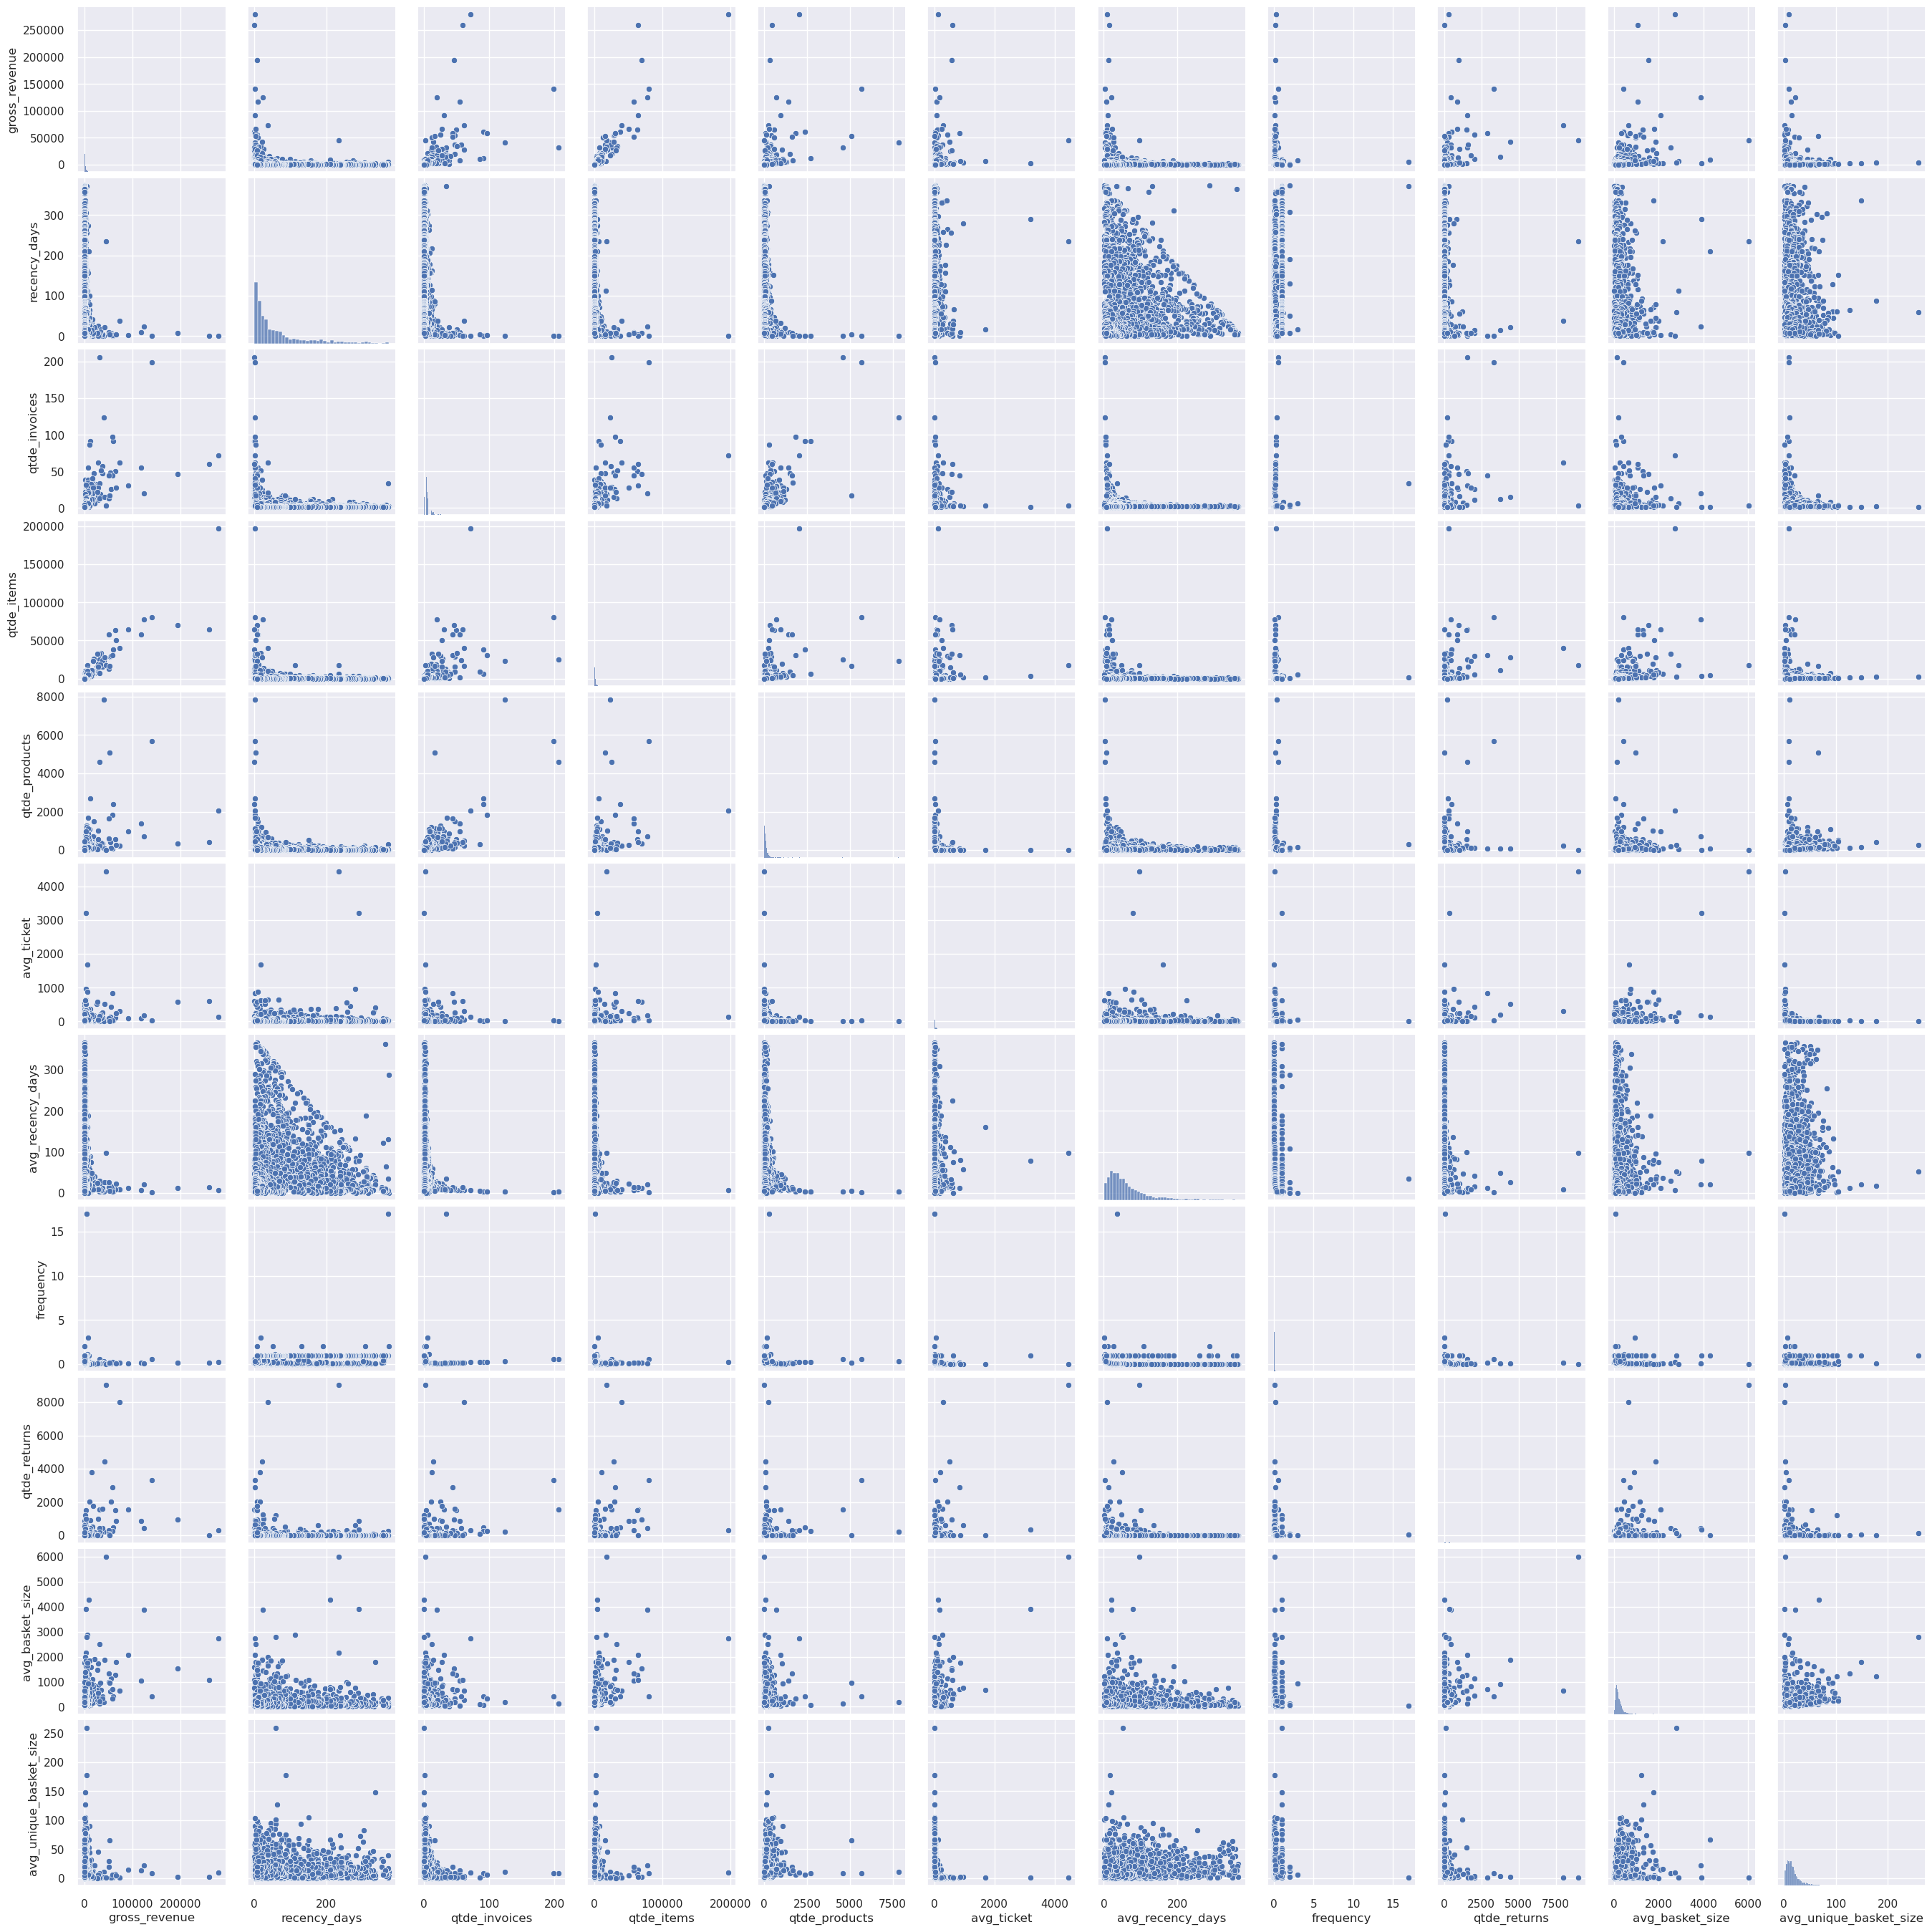

In [58]:
sns.pairplot(df42)
plt.show()

**Notes**

- avg_ticket, frequency, qtde_returns and avg_basket_size have low variance


## <span style="color:blue">4.3</span> Study of the Space of Embeddings

In [59]:
df43 = df4.drop(columns=["customer_id"], axis=1).copy()

In [51]:
# Initialize the MinMaxScaler
scaler = pp.MinMaxScaler()

# Select all numeric columns except 'customer_id'
cols_to_scale = df43.select_dtypes(include='number').columns

# Apply MinMax scaling only to the selected columns
df43[cols_to_scale] = scaler.fit_transform(df43[cols_to_scale])

X = df43.copy()

### 4.3.1 PCA

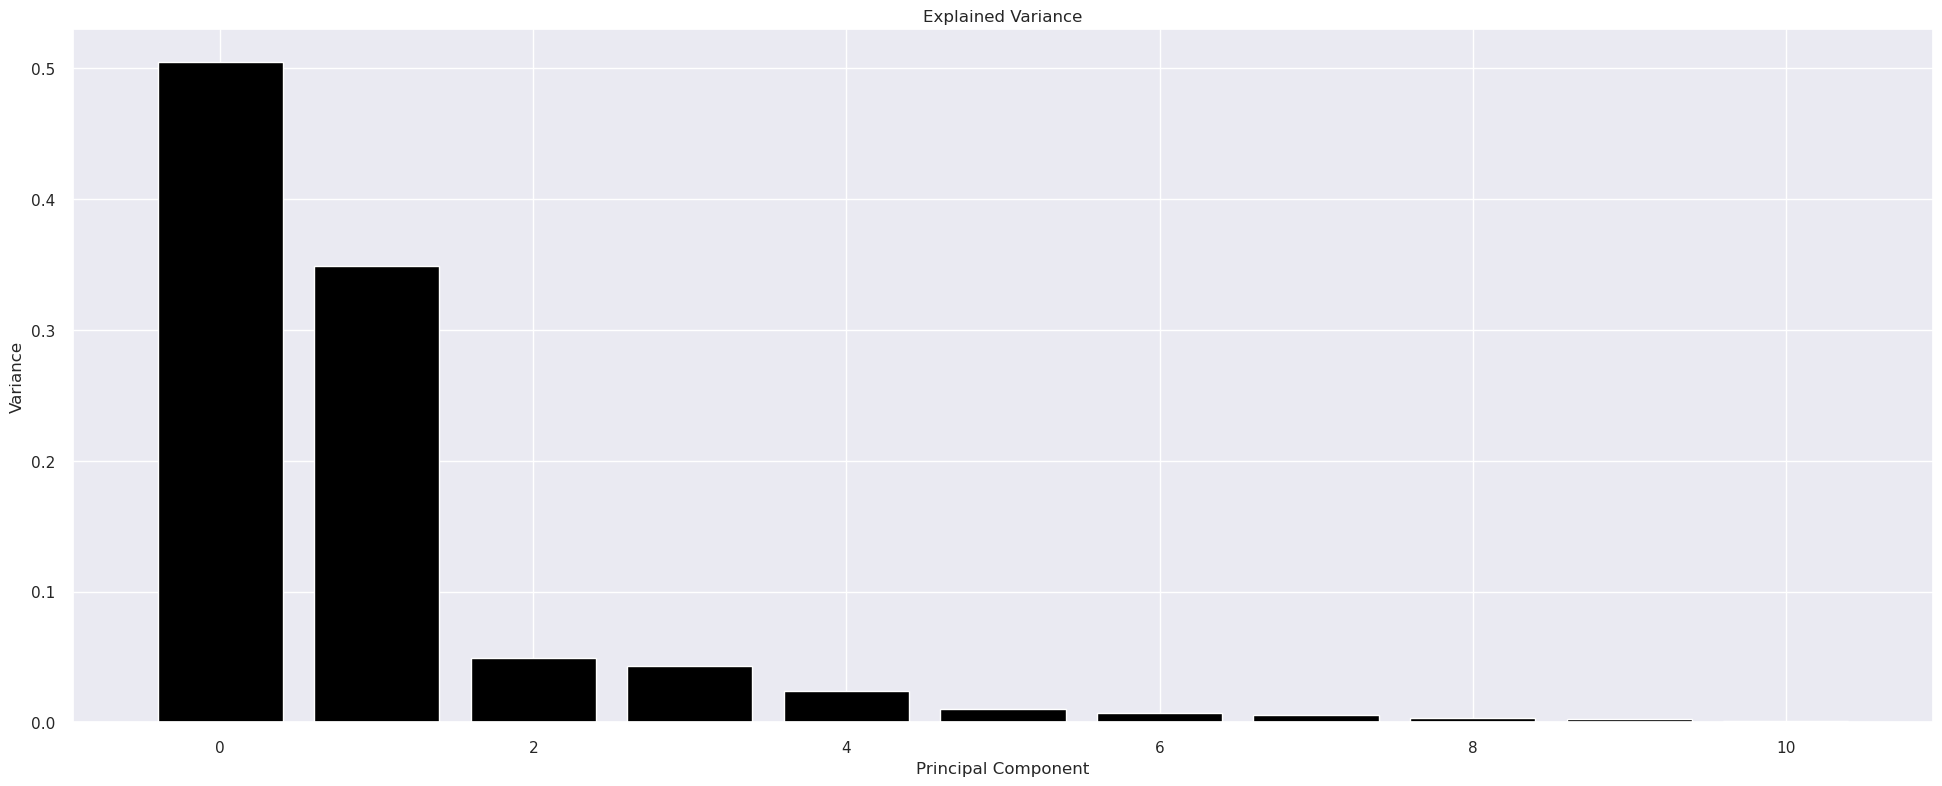

In [52]:

pca = PCA(n_components=X.shape[1])

principal_components = pca.fit_transform(X)

# plot explained variables
features = range(pca.n_components_)

plt.bar(features, pca.explained_variance_ratio_, color='black')
plt.xlabel('Principal Component')
plt.ylabel('Variance')
plt.title('Explained Variance')
plt.show()

# pca components
df_pca = pd.DataFrame(principal_components)

<Axes: xlabel='0', ylabel='1'>

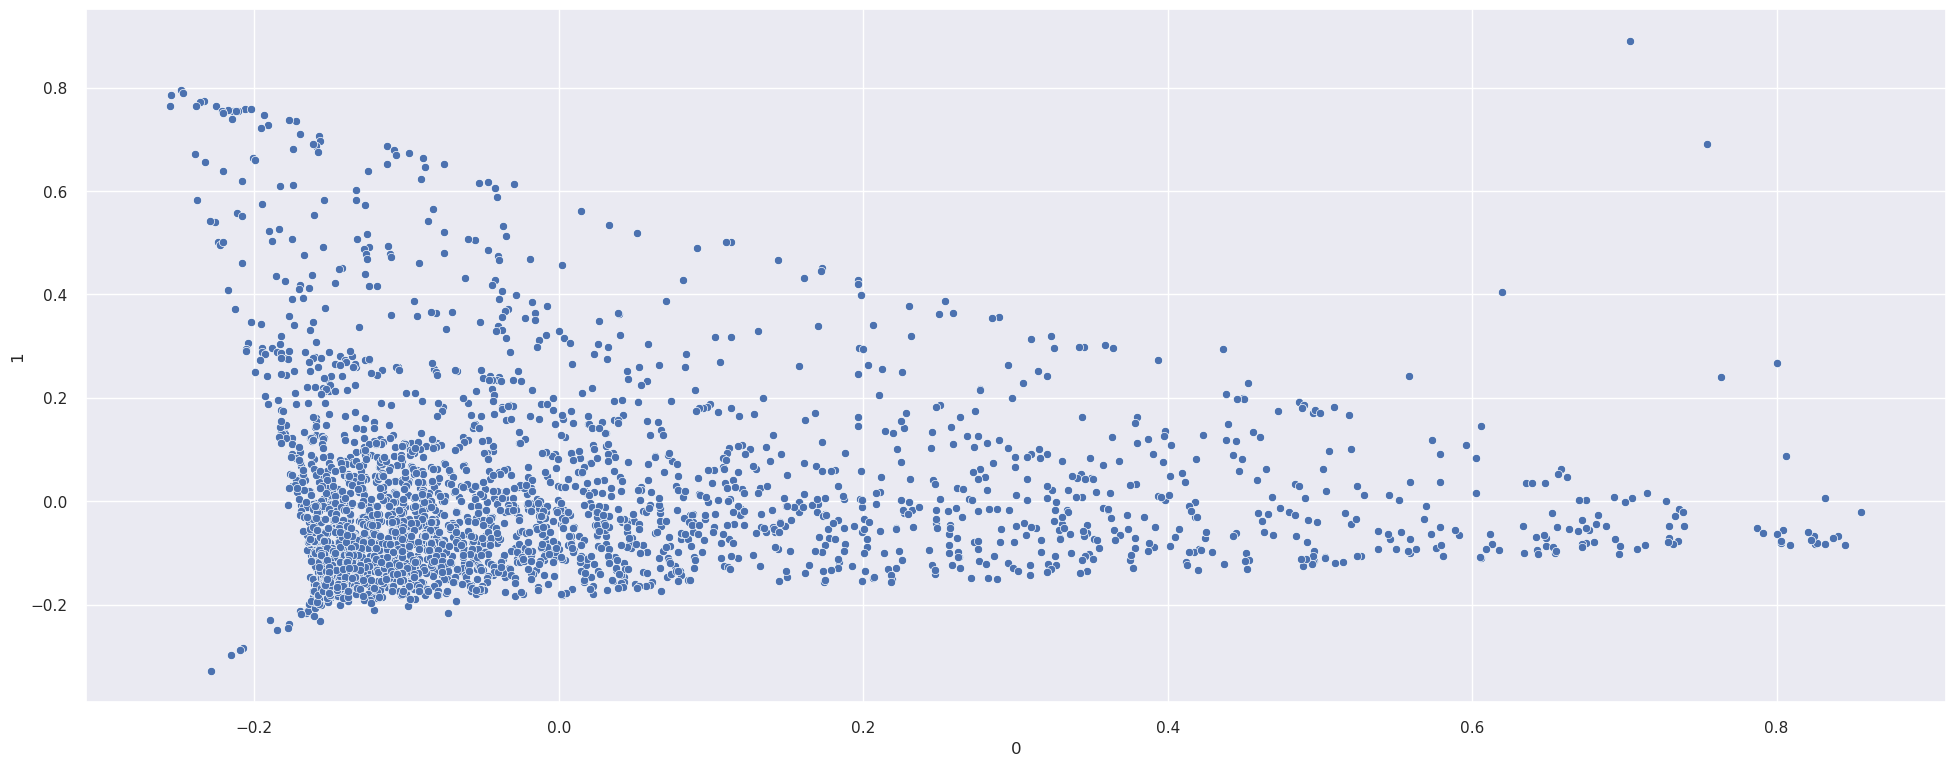

In [53]:
sns.scatterplot(x=0, y=1, data=df_pca)

### ⚠️ Why This PCA Distribution Is Not Suitable for Clustering

1. ❌ **No Clear Separable Groups**
   - The data forms a dense triangular cloud with no visible gaps or natural boundaries.
   - Points lie on a continuous gradient, not in distinct clusters.
   - Clustering algorithms (e.g., K-Means, DBSCAN) work best with well-separated, compact groups.

2. ❌ **High Overlap of Points**
   - Central overlap makes it difficult to distinguish cluster boundaries.
   - This can lead to arbitrary or poor clustering results.

3. ❌ **PCA Doesn’t Optimize for Clustering**
   - PCA focuses on capturing variance, not on separating clusters.
   - The top components may not reflect the actual cluster structure.
   - Variance directions might cut across potential groupings.

### 4.3.2 UMAP

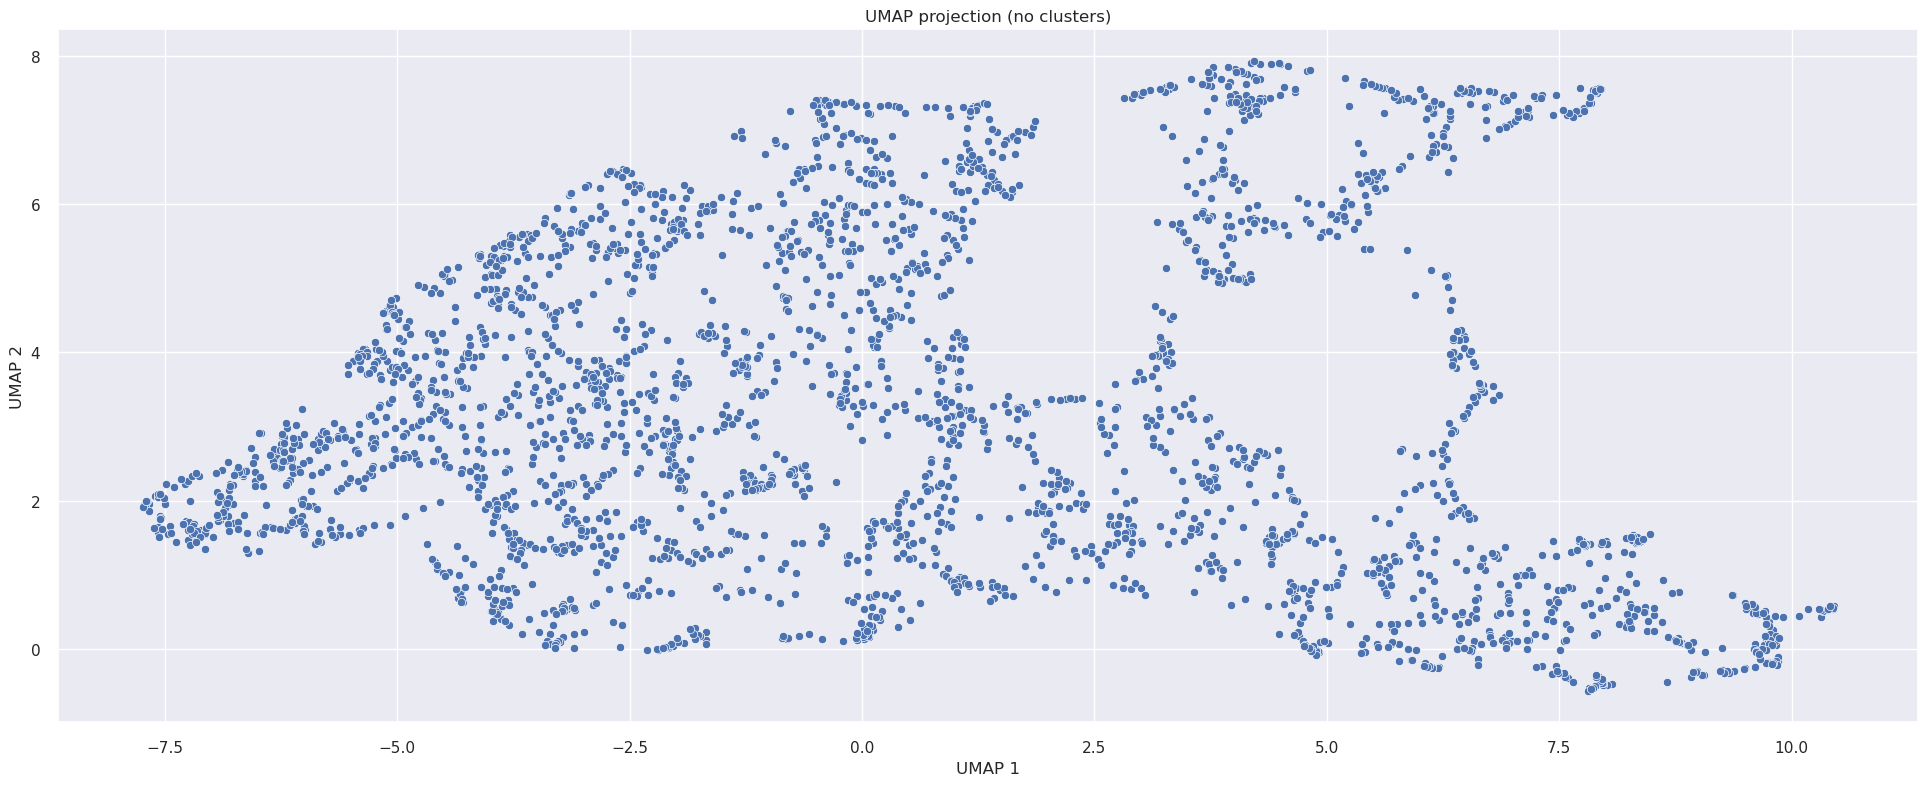

In [54]:
# Fit UMAP and transform the data
reducer = umap.UMAP(random_state=42)
embedding = reducer.fit_transform(X)

# Fit UMAP and transform the data
reducer = umap.UMAP(random_state=42)       # Initialize UMAP with fixed random seed
embedding = reducer.fit_transform(X)       # Fit UMAP on the data and transform it into 2D

# Create a new DataFrame with the UMAP embeddings
df_umap = pd.DataFrame({
    'embedding_x': embedding[:, 0],        # First UMAP component (x-axis)
    'embedding_y': embedding[:, 1]         # Second UMAP component (y-axis)
})

# Plot the UMAP results using seaborn (no clusters yet)
sns.scatterplot(
    x='embedding_x', 
    y='embedding_y', 
    data=df_umap
)

# Show the plot
plt.title('UMAP projection (no clusters)')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.show()

### 4.3.3 t-SNE

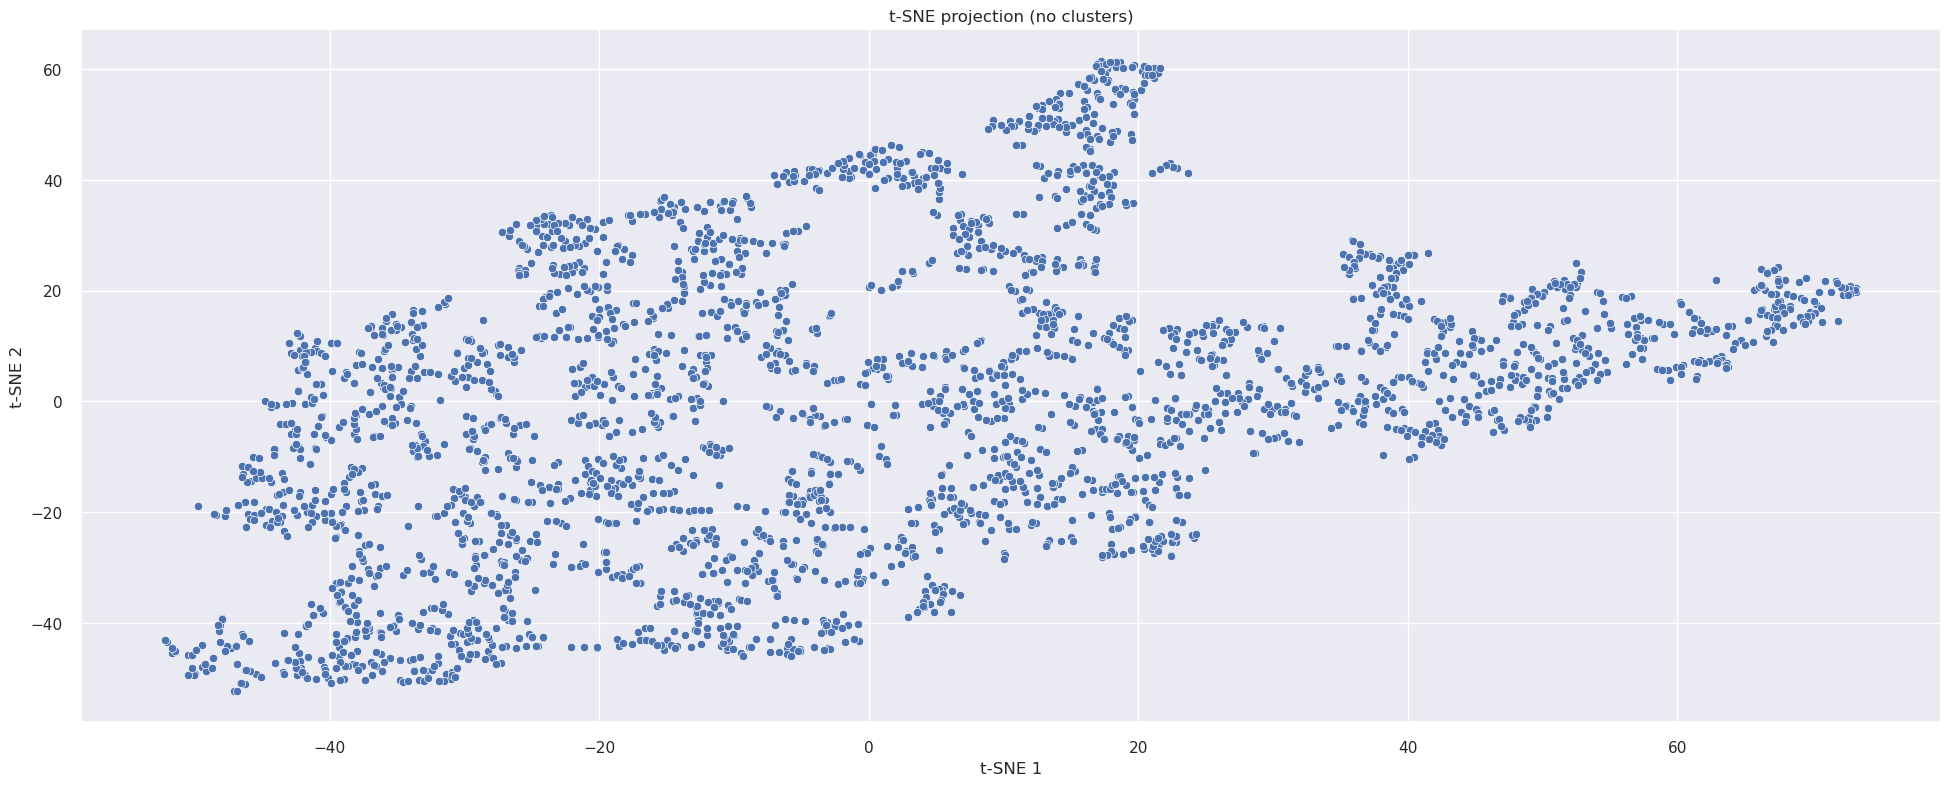

In [55]:
# Fit t-SNE and transform the data
tsne = TSNE(n_components=2, random_state=42, n_jobs=-1)   # Initialize t-SNE to reduce to 2 dimensions
embedding = tsne.fit_transform(X)              # Fit and transform the data (X should be scaled and 2D)

# Create a new DataFrame with the t-SNE embeddings
df_tsne = pd.DataFrame({
    'embedding_x': embedding[:, 0],            # First t-SNE component (x-axis)
    'embedding_y': embedding[:, 1]             # Second t-SNE component (y-axis)
})

# Plot the t-SNE results using seaborn (no clusters yet)
sns.scatterplot(
    x='embedding_x', 
    y='embedding_y', 
    data=df_tsne
)

# Show the plot
plt.title('t-SNE projection (no clusters)')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.show()

### 4.3.3 Tree-Based Embedding

In [56]:
# training dataset
X = df4.drop(columns=['customer_id', 'gross_revenue'], axis=1)
y = df4['gross_revenue']

# model definition
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# model training
rf_model.fit(X, y)

# Leaf
df_leaf = pd.DataFrame(rf_model.apply(X))

df_leaf.head()

,0,1,2,3,4,5,6,7,8,9,...,90,91,92,93,94,95,96,97,98,99
0,2991,2716,3326,3337,2284,3147,3227,3135,3166,3364,...,3186,3172,3176,3059,3044,3121,3187,2826,3356,3326
1,2960,2924,3042,2970,2739,3131,2924,2830,3110,2853,...,2509,2887,2883,2992,3145,3010,2911,2799,2964,2816
2,3632,3608,3587,3411,3570,3660,3634,3548,3679,3614,...,3598,3440,3560,3482,3601,3460,3528,3619,3568,3654
3,1278,1412,1763,1489,2017,1461,2102,1458,1656,1718,...,1877,1719,2026,1881,1936,2246,1467,1196,1988,2105
4,355,715,579,691,146,711,734,689,191,197,...,331,192,584,544,196,156,189,705,707,175


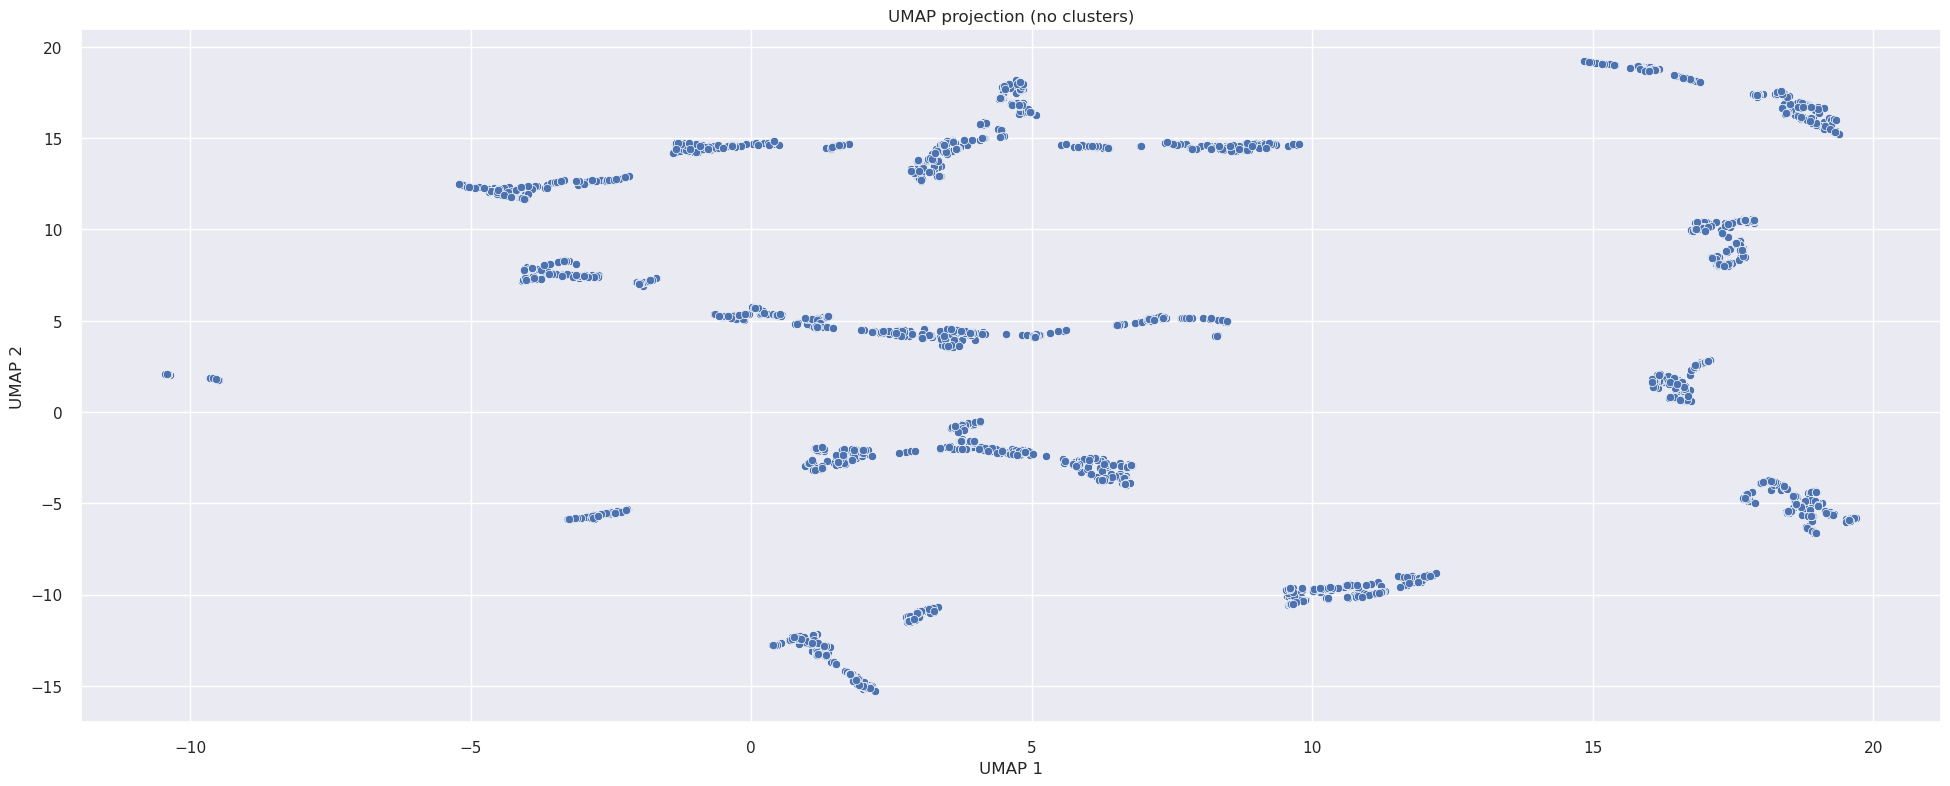

In [57]:
# Apply UMAP in df_leaf

# Fit UMAP and transform the data
reducer = umap.UMAP(random_state=42)       # Initialize UMAP with fixed random seed
embedding = reducer.fit_transform(df_leaf)       # Fit UMAP on the data and transform it into 2D

# Create a new DataFrame with the UMAP embeddings
df_umap = pd.DataFrame({
    'embedding_x': embedding[:, 0],        # First UMAP component (x-axis)
    'embedding_y': embedding[:, 1]         # Second UMAP component (y-axis)
})

# Plot the UMAP results using seaborn (no clusters yet)
sns.scatterplot(
    x='embedding_x', 
    y='embedding_y', 
    data=df_umap
)

# Show the plot
plt.title('UMAP projection (no clusters)')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.show()

# <font color='blue'> 🛠️ 5.0 Data Sculpting: Preparing for Modeling

## Practical guideline

When preprocessing numerical data, selecting the right scaler depends on the distribution of the feature and the presence of outliers. Below is a commonly used heuristic:

| Distribution Type              | Outliers Present? | Recommended Scaler  | Notes                                                                 |
|--------------------------------|------------------|----------------------|-----------------------------------------------------------------------|
| Approximately Normal           | No               | **StandardScaler**   | Centers around zero mean and unit variance. Good for Gaussian-like data. |
| Approximately Normal           | Yes              | **RobustScaler**     | Uses median and IQR, less sensitive to extreme values.                 |
| Non-Normal / Skewed            | Irrelevant       | **MinMaxScaler**     | Scales to fixed range [0, 1]. Useful for distance-based algorithms.    |

---

### Best Practices

- **Validate Distribution**  
  Don’t rely only on visual inspection. Use statistical tests (Shapiro-Wilk, Kolmogorov–Smirnov) and QQ-plots.  

- **Check Outliers**  
  Quantify outliers (IQR rule, Z-scores) before deciding on the scaler.  

- **Consider the Model**  
  - Scale-sensitive models: SVM, k-means, PCA, k-NN, Neural Networks.  
  - Less sensitive models: tree-based methods (Random Forest, XGBoost).  

- **Experiment and Compare**  
  Try different scalers and evaluate with cross-validation. Empirical results often outperform rigid rules.  

- **Pipeline Integration**  
  Always apply scaling inside a pipeline to prevent data leakage.  

- **Alternative Approaches**  
  - For skewed distributions: consider **log-transform**, **Box-Cox**, or **Yeo-Johnson** before scaling.  
  - For sparse data (e.g., TF-IDF vectors): scaling is often unnecessary.  

---

👉 This guideline is a **starting point**. The final choice of scaler must always be validated empirically for each dataset and model.

In [127]:
df5 = df4.copy()

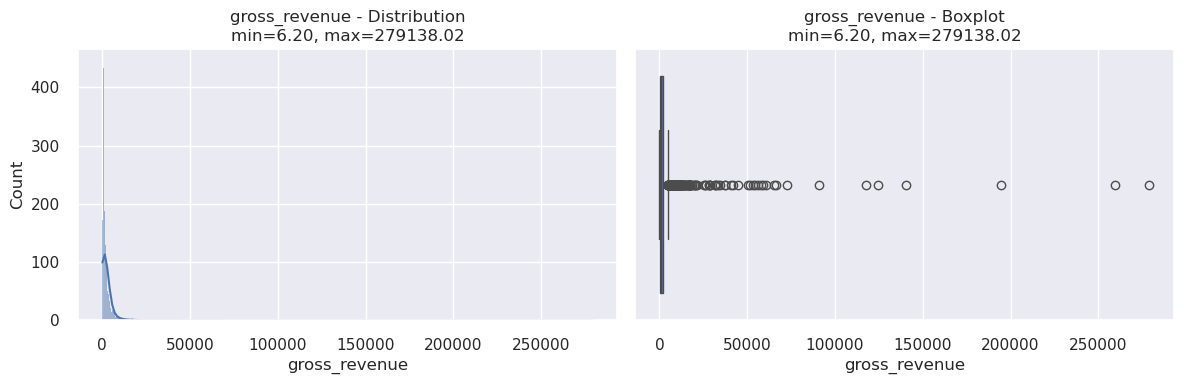

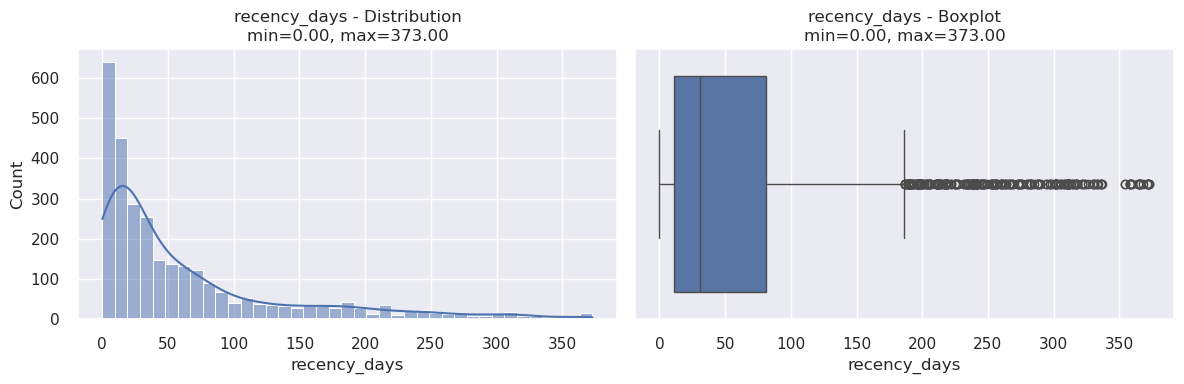

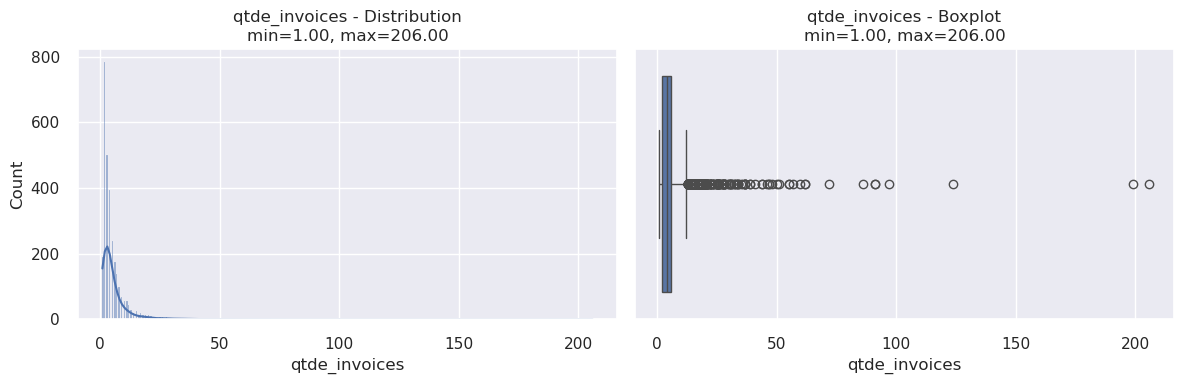

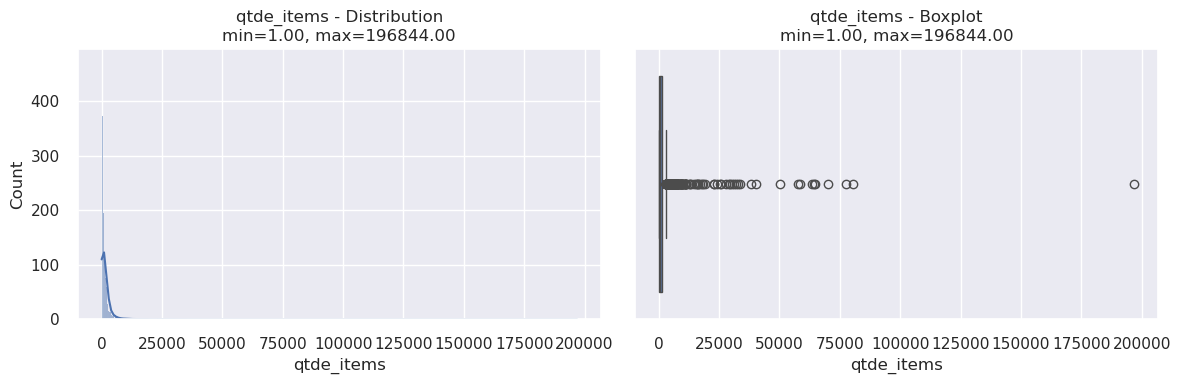

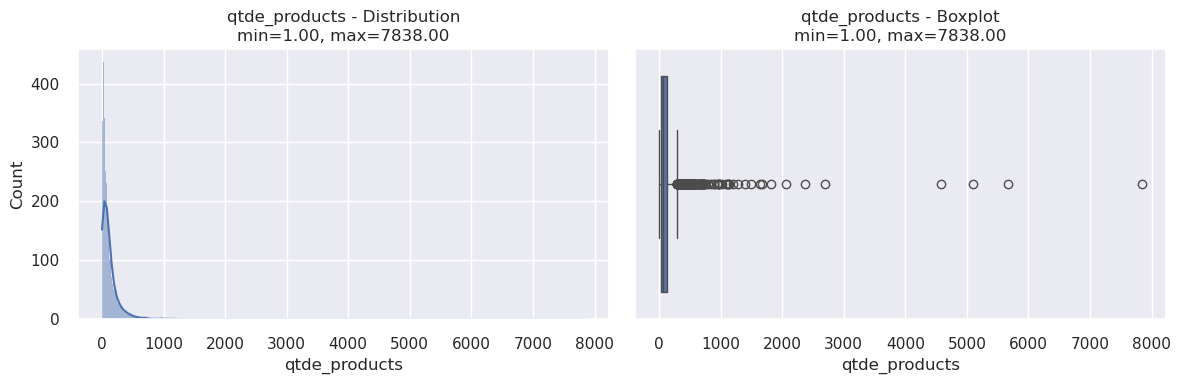

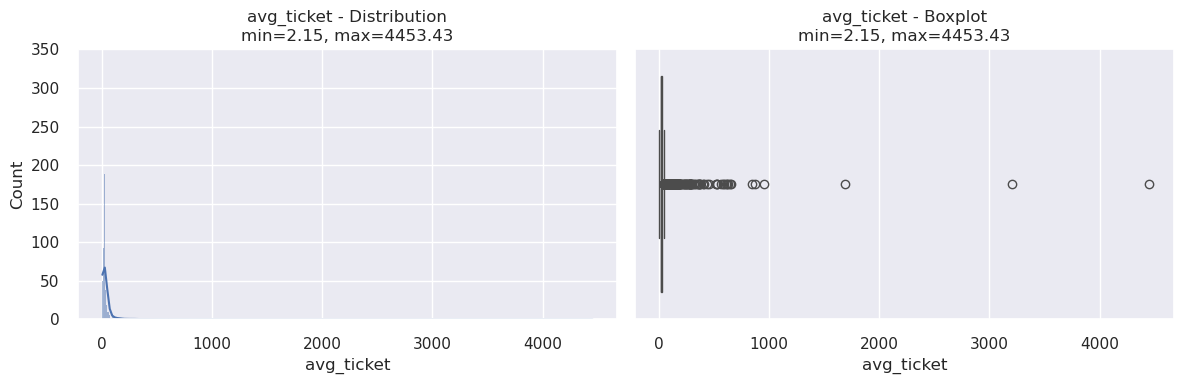

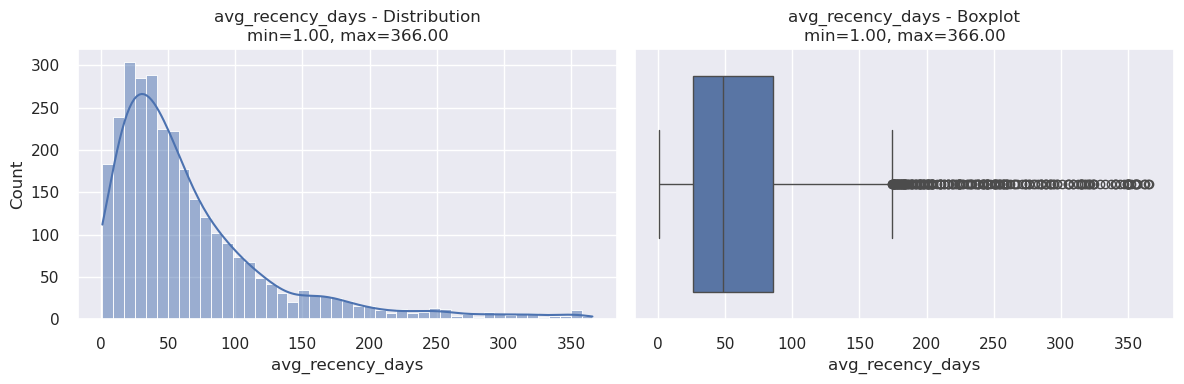

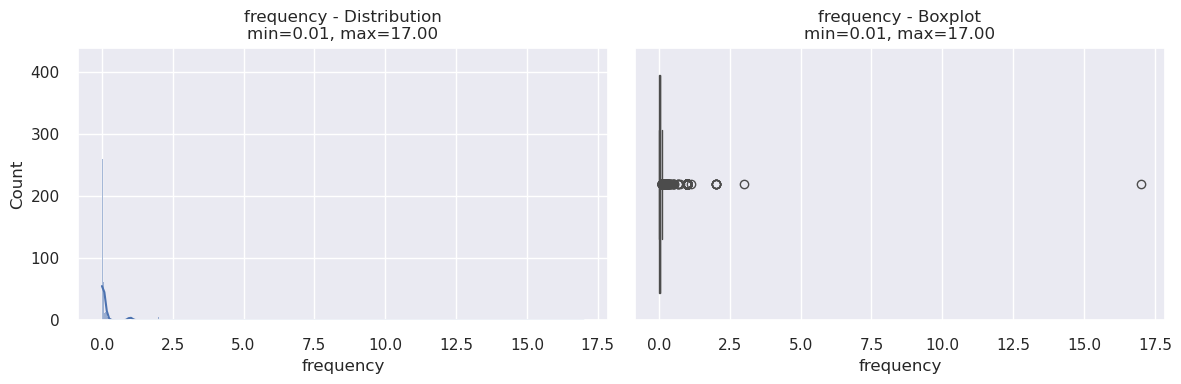

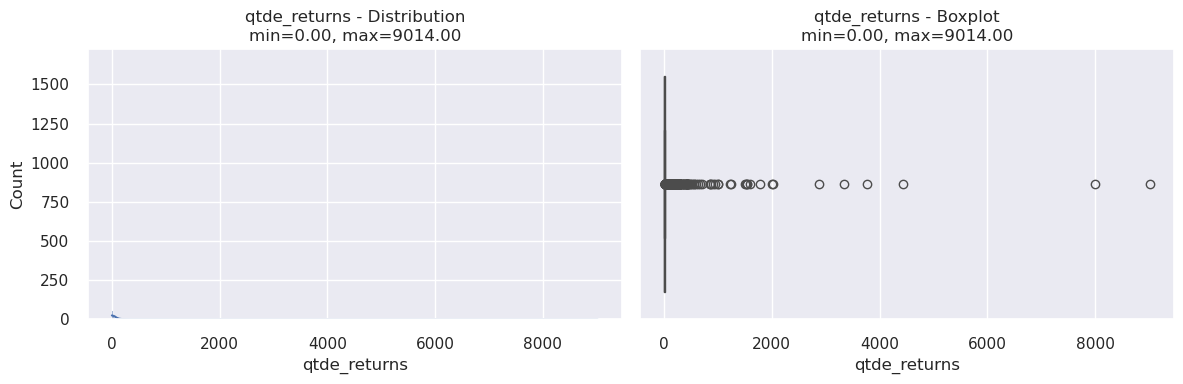

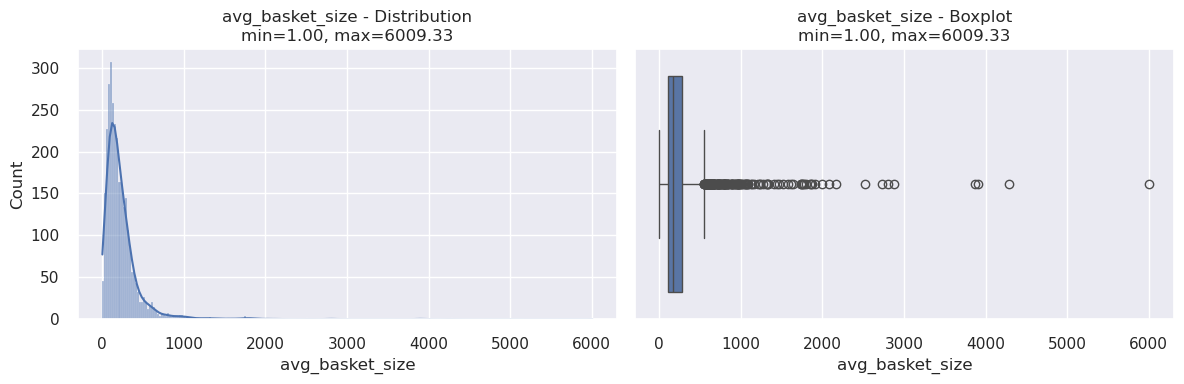

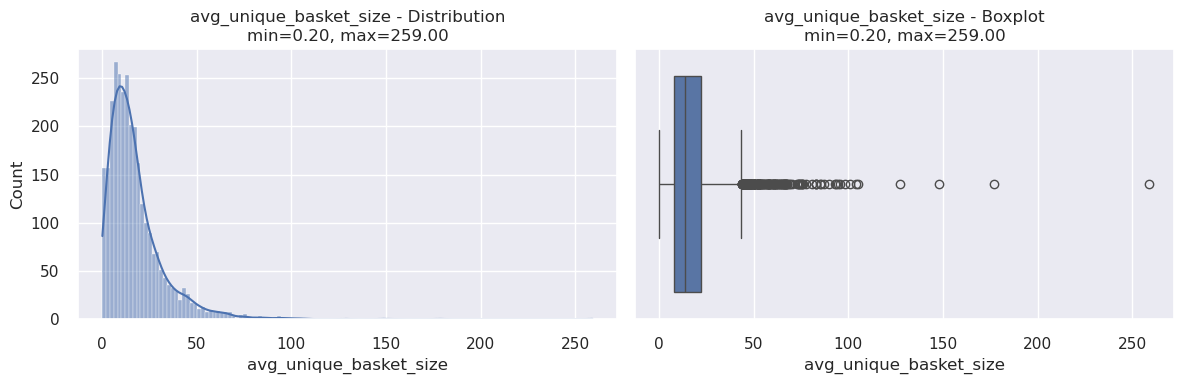

In [67]:
# Select only numerical columns from the dataframe
numeric_cols = df5.select_dtypes(include=['int64', 'float64']).columns
numeric_cols = [col for col in numeric_cols if col != 'customer_id']

# Criar os gráficos
for col in numeric_cols:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # --- Lado esquerdo: histograma + KDE ---
    sns.histplot(df5[col], kde=True, ax=axes[0])
    axes[0].set_title(f"{col} - Distribution\nmin={df5[col].min():.2f}, max={df5[col].max():.2f}")
    
    # --- Lado direito: boxplot ---
    sns.boxplot(x=df5[col], ax=axes[1])
    axes[1].set_title(f"{col} - Boxplot\nmin={df5[col].min():.2f}, max={df5[col].max():.2f}")
    
    plt.tight_layout()
    plt.show()


We will apply **MinMaxScaler** to all numerical variables. This decision is justified because:

1. Some variables do not follow a normal distribution, making StandardScaler or RobustScaler less appropriate in these cases.

2. MinMaxScaler preserves the shape of the original distribution while scaling all features to a fixed range [0, 1]. This is particularly useful for algorithms that are sensitive to feature scale, such as distance-based methods or neural networks.

3. Applying a uniform scaler simplifies preprocessing pipelines and ensures consistency across all features, while still allowing empirical evaluation of model performance.

4. The variables exhibit a long-tail distribution, which is typical in e-commerce data where most customers make only a few purchases and buy a limited number of products.

In [128]:
# Initialize MinMaxScalers
mm_gross_revenue = pp.MinMaxScaler()
mm_recency_days = pp.MinMaxScaler()
mm_qtde_products = pp.MinMaxScaler()
mm_frequency = pp.MinMaxScaler()
mm_qtde_returns = pp.MinMaxScaler()

# Apply MinMaxScaler only on selected numerical columns
df5['gross_revenue'] = mm_gross_revenue.fit_transform(df5[['gross_revenue']])
df5['recency_days'] = mm_recency_days.fit_transform(df5[['recency_days']])
df5['qtde_products'] = mm_qtde_products.fit_transform(df5[['qtde_products']])
df5['frequency'] = mm_frequency.fit_transform(df5[['frequency']])
df5['qtde_returns'] = mm_qtde_returns.fit_transform(df5[['qtde_returns']])

cols_selected = ['customer_id', 'gross_revenue', 'recency_days', 'qtde_products', 'frequency', 'qtde_returns'] 

# Verificar resultado
df5[cols_selected].head()

,customer_id,gross_revenue,recency_days,qtde_products,frequency,qtde_returns
0,17850,0.019292,0.997319,0.037770,1.000000,0.004438
1,13047,0.011559,0.150134,0.021692,0.001345,0.003883
2,12583,0.024000,0.005362,0.029476,0.002052,0.005547
3,13748,0.003375,0.254692,0.003445,0.000734,0.000000
4,15100,0.003116,0.892761,0.000255,0.003985,0.002441


# <font color='blue'> 🎯 6.0 Feature Spotlight: Selecting the Best Predictors

Unlike supervised learning, there are no traditional statistical methods to directly select the “best” variables in clustering, since there is no target variable to guide the process. Instead, the choice of features typically follows a combination of **business understanding** and **data-driven techniques**.

---

## Practical Steps for Feature Selection

### 1. Business Understanding  
Work closely with domain experts to identify which variables are most relevant for distinguishing meaningful segments (e.g., features that generalize well into customer personas).

### 2. Remove Redundant or Derived Features  
Exclude variables that are direct transformations of others, such as averages, ratios, or totals that introduce strong correlations (e.g., `avg_ticket` may be redundant if `gross_revenue` and `number_of_purchases` are already included).

### 3. Correlation Analysis  
Use correlation matrices or clustering of features to detect multicollinearity and drop highly correlated variables that do not add new information.

### 4. Variance and Distribution Check  
- Remove features with very low variance, since they do not help in separating clusters.  
- Consider transformations (e.g., log, Box-Cox, MinMax scaling) for long-tailed or skewed variables.

### 5. Dimensionality Reduction (Optional)  
Apply techniques such as **PCA**, **t-SNE**, or **UMAP** to reduce dimensionality, capture the most informative components, and mitigate the impact of correlated features.

### 6. Iterative Testing  
Experiment with different feature subsets and evaluate cluster quality using:  
- **Internal validation metrics**: Silhouette Score, Davies-Bouldin Index.  
- **External validation**: interpretability checks with domain experts.

---

👉 In summary, **feature selection for clustering is less about strict statistical rules and more about combining domain knowledge with exploratory analysis and validation metrics.**

In [ ]:
df6 = df5.copy()

,customer_id,gross_revenue,recency_days,qtde_products,frequency,qtde_returns
0,17850,0.019292,0.997319,0.037770,1.000000,0.004438
1,13047,0.011559,0.150134,0.021692,0.001345,0.003883
2,12583,0.024000,0.005362,0.029476,0.002052,0.005547
3,13748,0.003375,0.254692,0.003445,0.000734,0.000000
4,15100,0.003116,0.892761,0.000255,0.003985,0.002441


# <font color='blue'> 🔍 7.0 Hyperparameter Fine-Tuning

In [72]:
X = df6.drop(columns=['customer_id']).copy()

In [73]:
clusters = np.arange(2, 8)
clusters

array([2, 3, 4, 5, 6, 7])

## <span style="color:blue">7.1</span> K-Means

In [74]:
kmeans_sil_list = []

for k in clusters:
    
    # model definition
    kmeans_model = KMeans(n_clusters=k, random_state=42)

    # model training
    kmeans_model.fit(X)

    # model predict
    labels = kmeans_model.predict(X)

    # model performance
    kmeans_sil_list.append(silhouette_score(X, labels, metric='euclidean'))

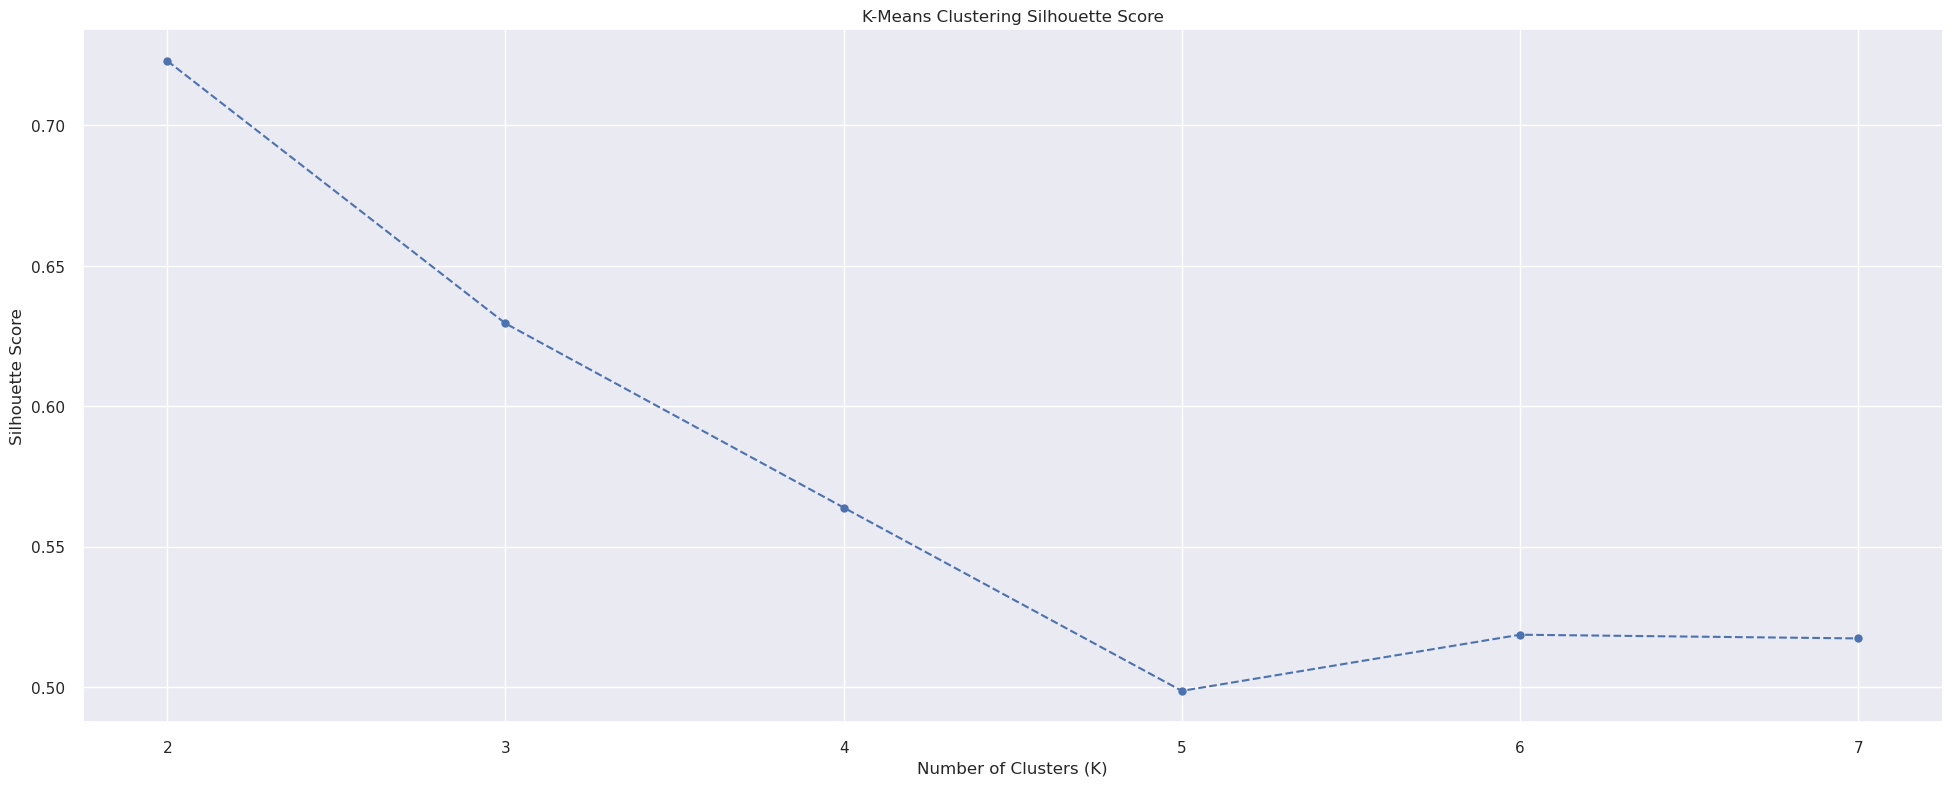

In [75]:
plt.plot(clusters, kmeans_sil_list, linestyle='--', marker='o', color='b')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('K-Means Clustering Silhouette Score')
plt.show()

## <span style="color:blue">7.2</span> GMM

In [76]:
gmm_sil_list = []

for k in clusters:

    # model definition
    gmm_model = GaussianMixture(n_components=k, random_state=42)

    # model training
    gmm_model.fit(X)

    # model predict
    gmm_labels = gmm_model.predict(X)

    # model performance
    gmm_sil_list.append(silhouette_score(X, gmm_labels, metric='euclidean'))

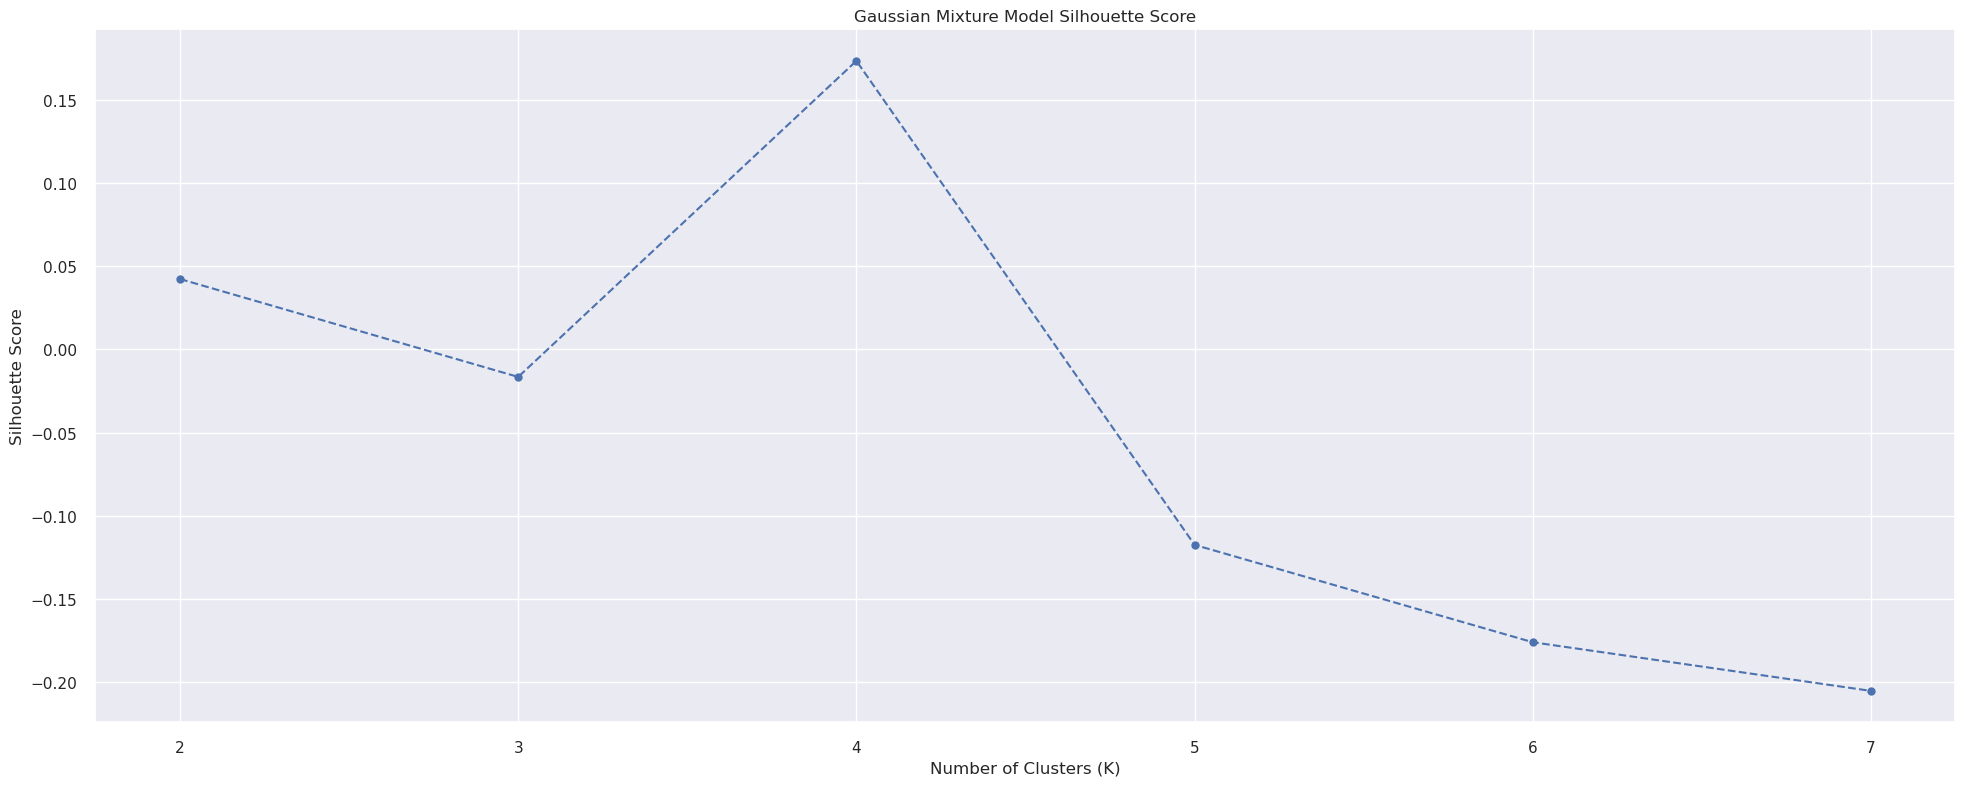

In [77]:
plt.plot(clusters, gmm_sil_list, linestyle='--', marker='o', color='b')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Gaussian Mixture Model Silhouette Score')
plt.show()

## <span style="color:blue">7.3</span> Hierarchical Clustering

[]

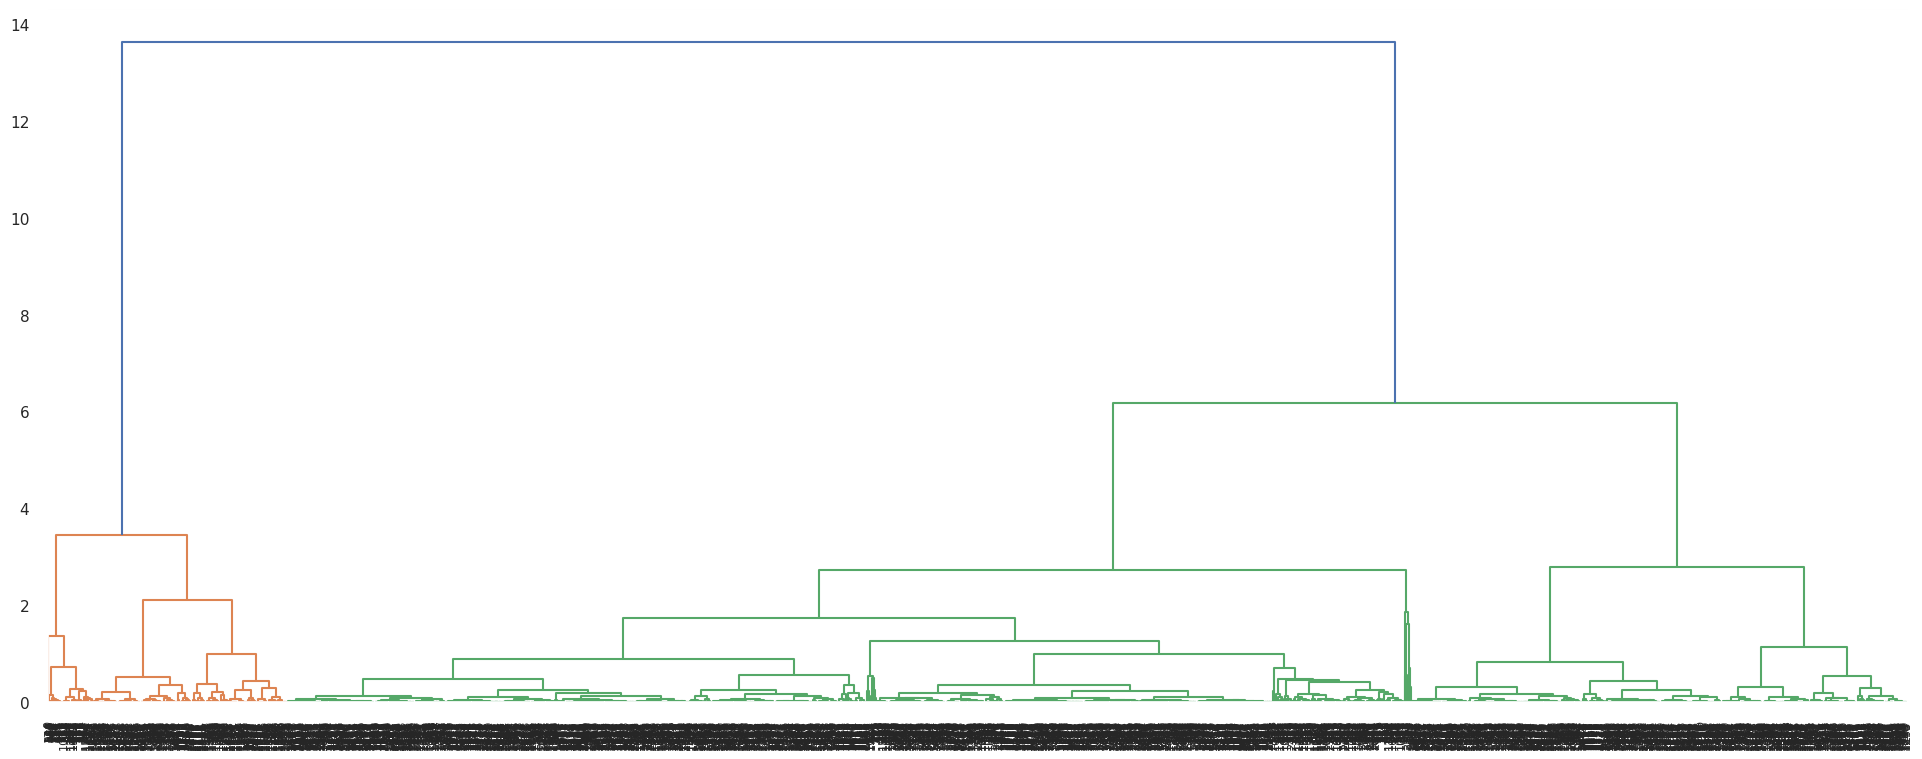

In [78]:
# model definition and training
from scipy.cluster import hierarchy as hc

# model definition
hc_model = hc.linkage(X, method='ward')

hc.dendrogram(
    hc_model,
    leaf_rotation=90,
    leaf_font_size=8,
)

plt.plot()

[]

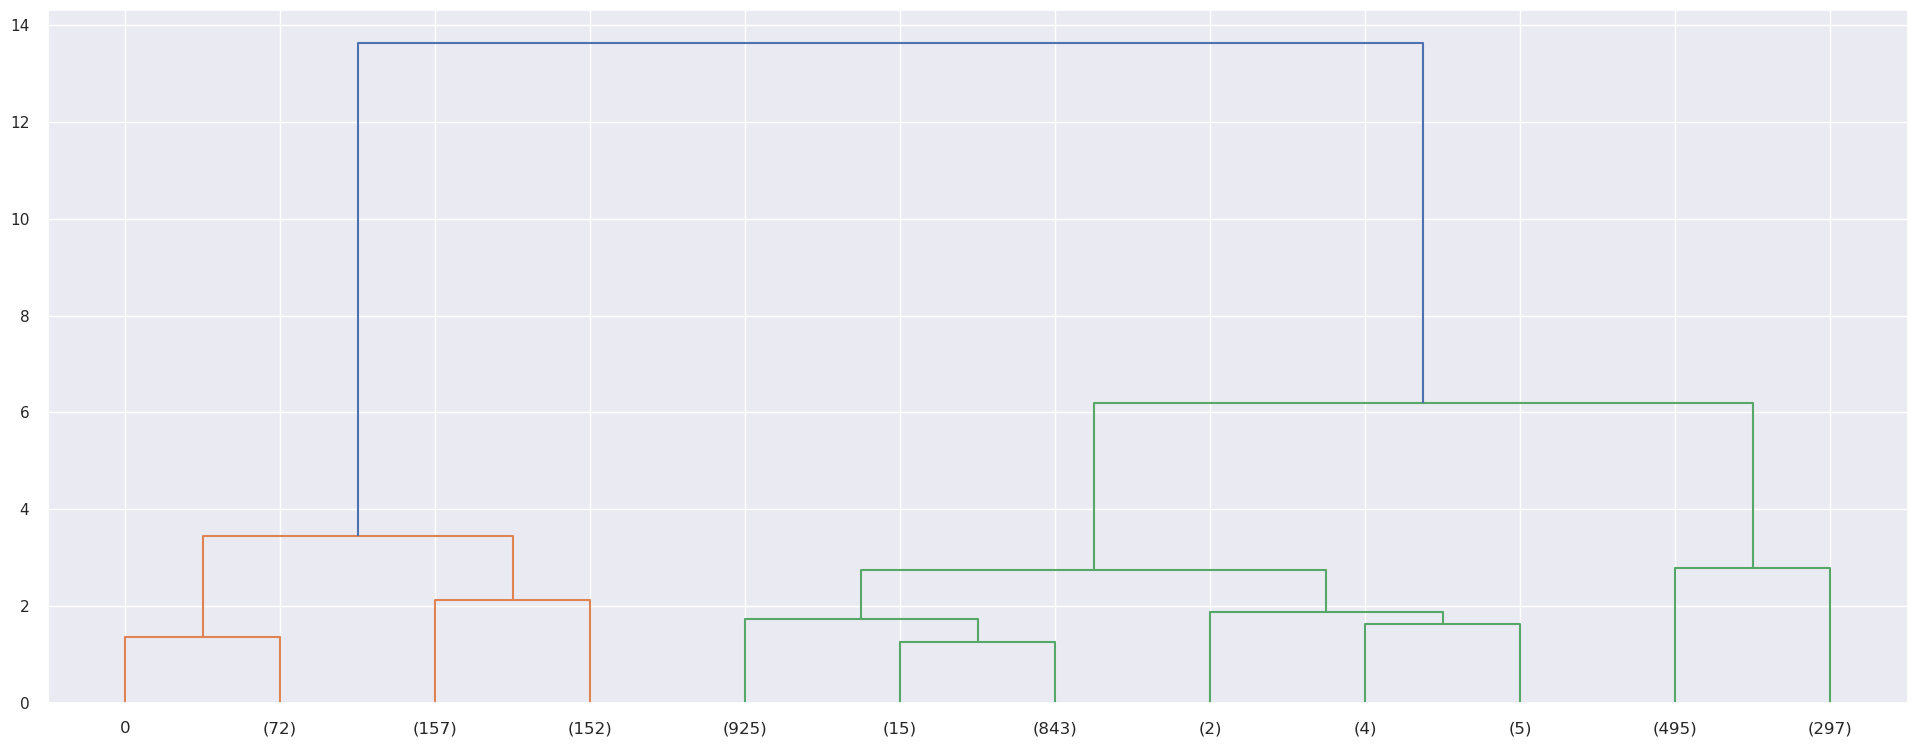

In [79]:
hc.dendrogram(
    hc_model,
    truncate_mode='lastp',
    p=12
)

plt.plot()

k=2 → Silhouette Score: 0.721
k=3 → Silhouette Score: 0.571
k=4 → Silhouette Score: 0.563
k=5 → Silhouette Score: 0.496
k=6 → Silhouette Score: 0.515
k=7 → Silhouette Score: 0.516


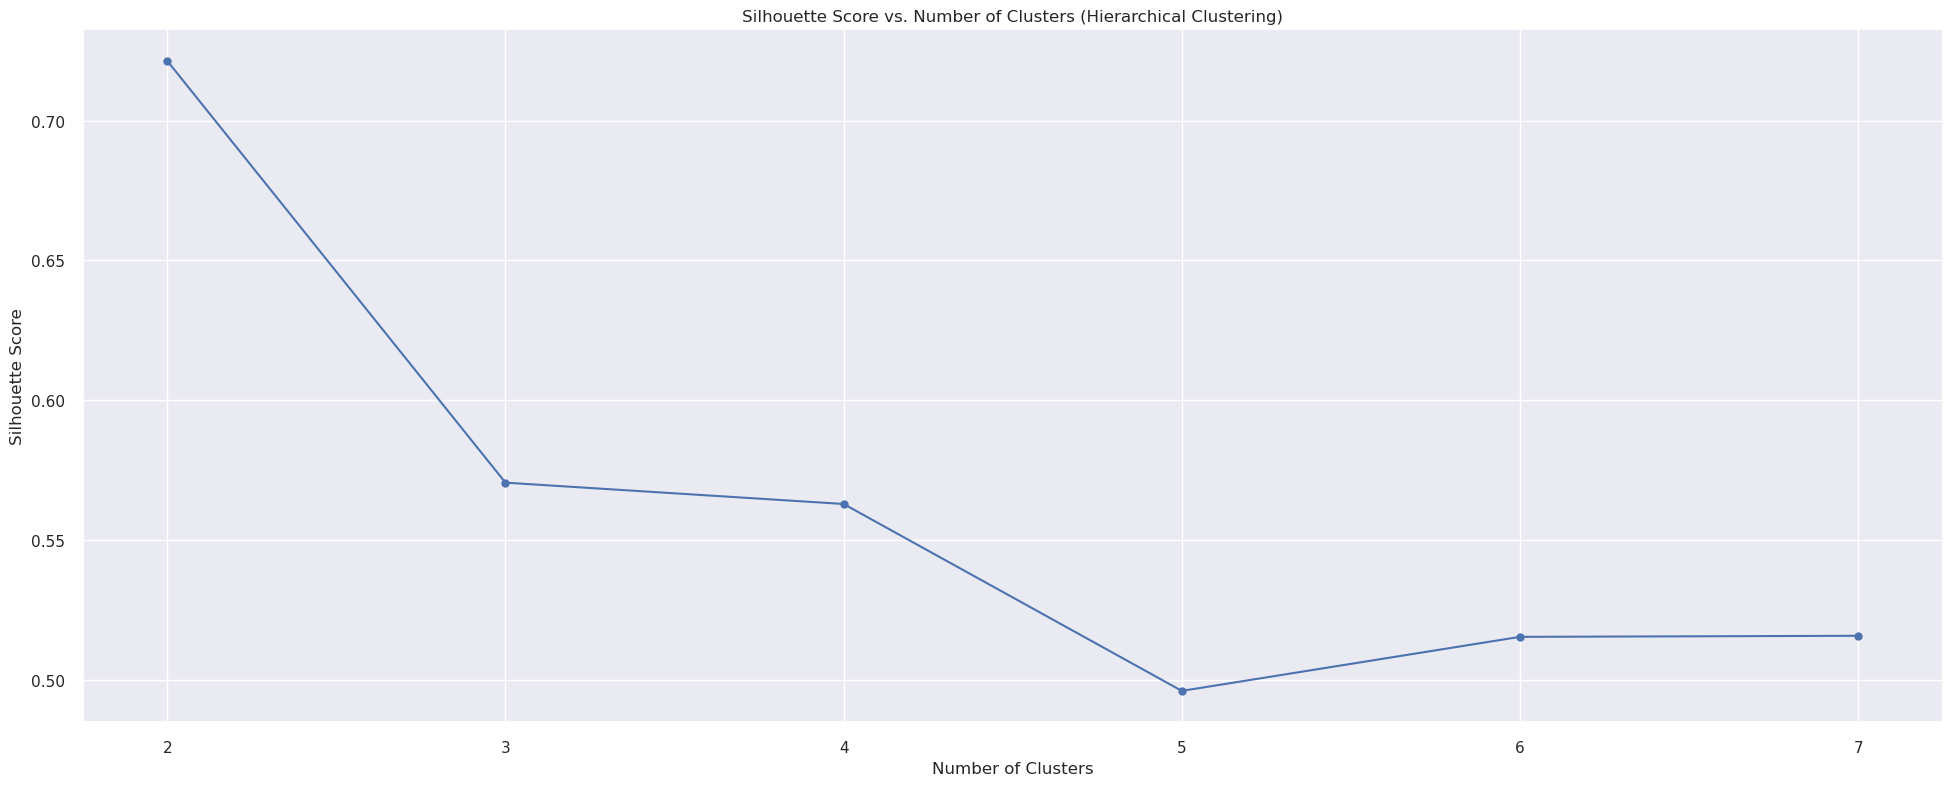

In [80]:
from scipy.cluster.hierarchy import fcluster

# list to store silhouette scores
hc_sil_list = []

# Loop through each number of clusters
for k in clusters:
    # Get cluster labels by cutting the dendrogram into k clusters
    labels = fcluster(hc_model, k, criterion='maxclust')

    # Calculate silhouette score for the current k
    score = silhouette_score(X, labels, metric='euclidean')
    hc_sil_list.append(score)

# Print results
for k, score in zip(clusters, hc_sil_list):
    print(f"k={k} → Silhouette Score: {score:.3f}")

# Plot silhouette scores
plt.plot(clusters, hc_sil_list, marker='o')
plt.title("Silhouette Score vs. Number of Clusters (Hierarchical Clustering)")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.show()

## <span style="color:blue">7.4</span> DBSCAN

In [83]:
min_samples = 20

# model definition
db_scan_model = DBSCAN(eps=0.01, min_samples=min_samples)

# model training & prediction
labels = db_scan_model.fit_predict(X)

score = silhouette_score(X, labels, metric='euclidean')

# Convert labels to a unique list and remove "-1" -> It's the label for noise points
unique_clusters = np.unique(labels).tolist()
if -1 in unique_clusters:
    print('tem noise')
    unique_clusters.remove(-1)

print(f"k={len(unique_clusters)} → Silhouette Score: {score:.3f}")

tem noise
k=5 → Silhouette Score: 0.191


### <span style="color:blue">7.4.1 </span> K-dist plot method to choose eps

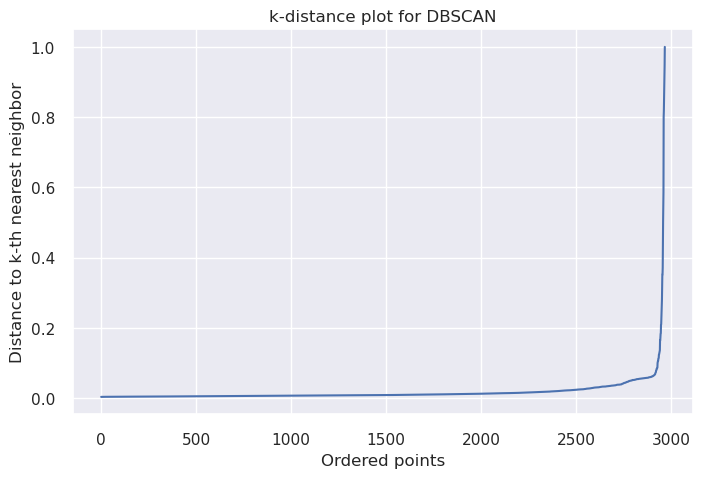

In [82]:
from sklearn.neighbors import NearestNeighbors

# Set up the nearest neighbors model
# 'min_samples' is the number of neighbors to consider (DBSCAN parameter)
neighbors = NearestNeighbors(n_neighbors=min_samples)

# Fit the model to the data X
neighbors_fit = neighbors.fit(X)

# Compute distances to the k nearest neighbors for each point
distances, indices = neighbors_fit.kneighbors(X)

# Sort the distances to the k-th nearest neighbor (last column)
# This is used to visualize the "elbow" in the k-distance graph
distances = np.sort(distances[:, -1], axis=0)

# Plot the k-distance graph
# This helps to select the optimal epsilon value for DBSCAN
plt.figure(figsize=(8,5))
plt.plot(distances)
plt.ylabel('Distance to k-th nearest neighbor')
plt.xlabel('Ordered points')
plt.title('k-distance plot for DBSCAN')
plt.show()

### <span style="color:blue">7.4.2 </span> Grid search with clustering metrics

In [84]:
best_score = -1
best_eps = None
best_min_samples = None
best_clusters = None
best_labels = None

# Candidate values for eps and min_samples
eps_values = np.linspace(0.02, 0.30, 30)  # adjust according to your dataset scale
min_samples_values = range(3, 21)  # from 3 to 20

# Dicionário para armazenar melhores parâmetros por número de clusters
best_per_k = {}

for eps in eps_values:
    for min_samples in min_samples_values:
        # Define and fit DBSCAN
        db_scan_model = DBSCAN(eps=eps, min_samples=min_samples)
        labels = db_scan_model.fit_predict(X)
        
        # Clusters excluding noise
        clusters_no_noise = [c for c in np.unique(labels) if c != -1]
        k = len(clusters_no_noise)
        
        # Skip if less than 2 clusters
        if k < 2:
            continue
        
        # Compute silhouette score
        score = silhouette_score(X, labels, metric='euclidean')
        
        # Penalize by noise ratio
        noise_ratio = np.sum(labels == -1) / len(labels)
        adjusted_score = score * (1 - noise_ratio)
        
        # Update best for this k if score improves
        if (k not in best_per_k) or (adjusted_score > best_per_k[k]['adjusted_score']):
            best_per_k[k] = {
                'eps': eps,
                'min_samples': min_samples,
                'adjusted_score': adjusted_score,
                'num_noise': np.sum(labels == -1)
            }

# Print results grouped by number of clusters
for k, info in sorted(best_per_k.items()):
    print(f"{k} clusters → eps: {info['eps']:.3f}, min_samples: {info['min_samples']}, "
          f"noise points: {info['num_noise']}, adjusted silhouette: {info['adjusted_score']:.3f}")

2 clusters → eps: 0.261, min_samples: 3, noise points: 7, adjusted silhouette: 0.768
3 clusters → eps: 0.039, min_samples: 19, noise points: 143, adjusted silhouette: 0.510
4 clusters → eps: 0.039, min_samples: 17, noise points: 122, adjusted silhouette: 0.509
5 clusters → eps: 0.030, min_samples: 7, noise points: 73, adjusted silhouette: 0.406
6 clusters → eps: 0.039, min_samples: 16, noise points: 75, adjusted silhouette: 0.414
7 clusters → eps: 0.030, min_samples: 12, noise points: 134, adjusted silhouette: 0.395
9 clusters → eps: 0.020, min_samples: 9, noise points: 190, adjusted silhouette: -0.182
11 clusters → eps: 0.020, min_samples: 8, noise points: 166, adjusted silhouette: -0.172
12 clusters → eps: 0.020, min_samples: 7, noise points: 151, adjusted silhouette: -0.170
13 clusters → eps: 0.020, min_samples: 6, noise points: 137, adjusted silhouette: -0.253


In [85]:
# Lista de scores de k=2 até k=7
dbscan_sil_list = []

for k in range(2, 8):  # 2, 3, 4, 5, 6, 7
    if k in best_per_k:
        dbscan_sil_list.append(best_per_k[k]['adjusted_score'])
    else:
        dbscan_sil_list.append(0)

## <span style="color:blue">7.5</span> Results

In [86]:
df_results = pd.DataFrame(
    {'Kmeans': kmeans_sil_list,
     'GMM': gmm_sil_list,
     'Hierarchical': hc_sil_list,
     'DBSCAN': dbscan_sil_list}
).T

df_results.columns = clusters

df_results.style.highlight_max(color='lightgreen', axis=1)

,2,3,4,5,6,7
Kmeans,0.722958,0.629452,0.563871,0.498577,0.518582,0.517264
GMM,0.042310,-0.016524,0.173423,-0.117458,-0.175978,-0.205221
Hierarchical,0.721382,0.570514,0.562887,0.496029,0.515360,0.515740
DBSCAN,0.768234,0.510007,0.508999,0.405742,0.413670,0.395217


## <span style="color:blue">7.6</span> Silhouette Analysis

In [89]:
def plot_silhouette_facet(X, clusters, model_type="kmeans", **kwargs):
    """
    Generate silhouette plots for different values of k/clusters.

    Parameters
    ----------
    X : array-like, shape (n_samples, n_features)
        Input data.
    
    clusters : list
        List of cluster numbers to evaluate (ignored for DBSCAN).
    
    model_type : str
        Clustering algorithm: "kmeans", "gmm", "hc", or "dbscan".
    
    **kwargs :
        Additional parameters passed to the clustering algorithm.
    """

    n_cols = 2
    n_rows = int(np.ceil(len(clusters) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows))
    axes = axes.flatten()

    for idx, k in enumerate(clusters):

        # --- fit model based on type ---
        if model_type == "kmeans":
            model = KMeans(n_clusters=k, random_state=42, **kwargs).fit(X)
            labels = model.labels_

        elif model_type == "gmm":
            model = GaussianMixture(n_components=k, random_state=42, **kwargs).fit(X)
            labels = model.predict(X)

        elif model_type == "hc":
            hc_model = hc.linkage(X, method=kwargs.get("method", "ward"))
            labels = hc.fcluster(hc_model, k, criterion='maxclust')

        elif model_type == "dbscan":
            model = DBSCAN(**kwargs).fit(X)
            labels = model.labels_

            # skip silhouette if only 1 cluster found
            n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
            if n_clusters <= 1:
                print(f"DBSCAN with params {kwargs} found only one cluster. Skipping silhouette.")
                continue
            k = None  # DBSCAN does not use fixed k

        else:
            raise ValueError("Invalid model_type. Choose from 'kmeans', 'gmm', 'hc', 'dbscan'.")

        # --- silhouette metrics ---
        ss = silhouette_score(X, labels)
        sample_silhouette_values = silhouette_samples(X, labels)

        # effective number of clusters (for plotting)
        k_effective = len(np.unique(labels)) if model_type == "dbscan" else k

        ax = axes[idx]
        ax.set_xlim([-0.1, 1])
        ax.set_ylim([0, len(X) + (k_effective + 1) * 10])

        y_lower = 10
        for i, cluster_id in enumerate(np.unique(labels), start=1):
            ith_values = sample_silhouette_values[labels == cluster_id]
            ith_values.sort()

            size_cluster = ith_values.shape[0]
            y_upper = y_lower + size_cluster

            cmap = plt.cm.get_cmap("Spectral")
            color = cmap(float(i) / k_effective)
            ax.fill_betweenx(np.arange(y_lower, y_upper),
                             0, ith_values,
                             facecolor=color, edgecolor=color, alpha=0.7)

            ax.text(-0.05, y_lower + 0.5 * size_cluster, str(cluster_id))
            y_lower = y_upper + 10

        # vertical line for avg silhouette
        ax.axvline(x=ss, color="red", linestyle="--")

        # titles and labels
        if model_type == "dbscan":
            title = f"DBSCAN (eps={kwargs.get('eps')}, min_samples={kwargs.get('min_samples')})\nMean silhouette={ss:.3f}"
        else:
            title = f"{model_type.upper()} k={k}\nMean silhouette={ss:.3f}"

        ax.set_title(title)
        ax.set_xlabel("Silhouette coefficient")
        ax.set_ylabel("Clusters")
        ax.set_yticks([])
        ax.set_xticks(np.linspace(-0.1, 1.0, 6))

    # remove unused subplots
    for j in range(idx + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

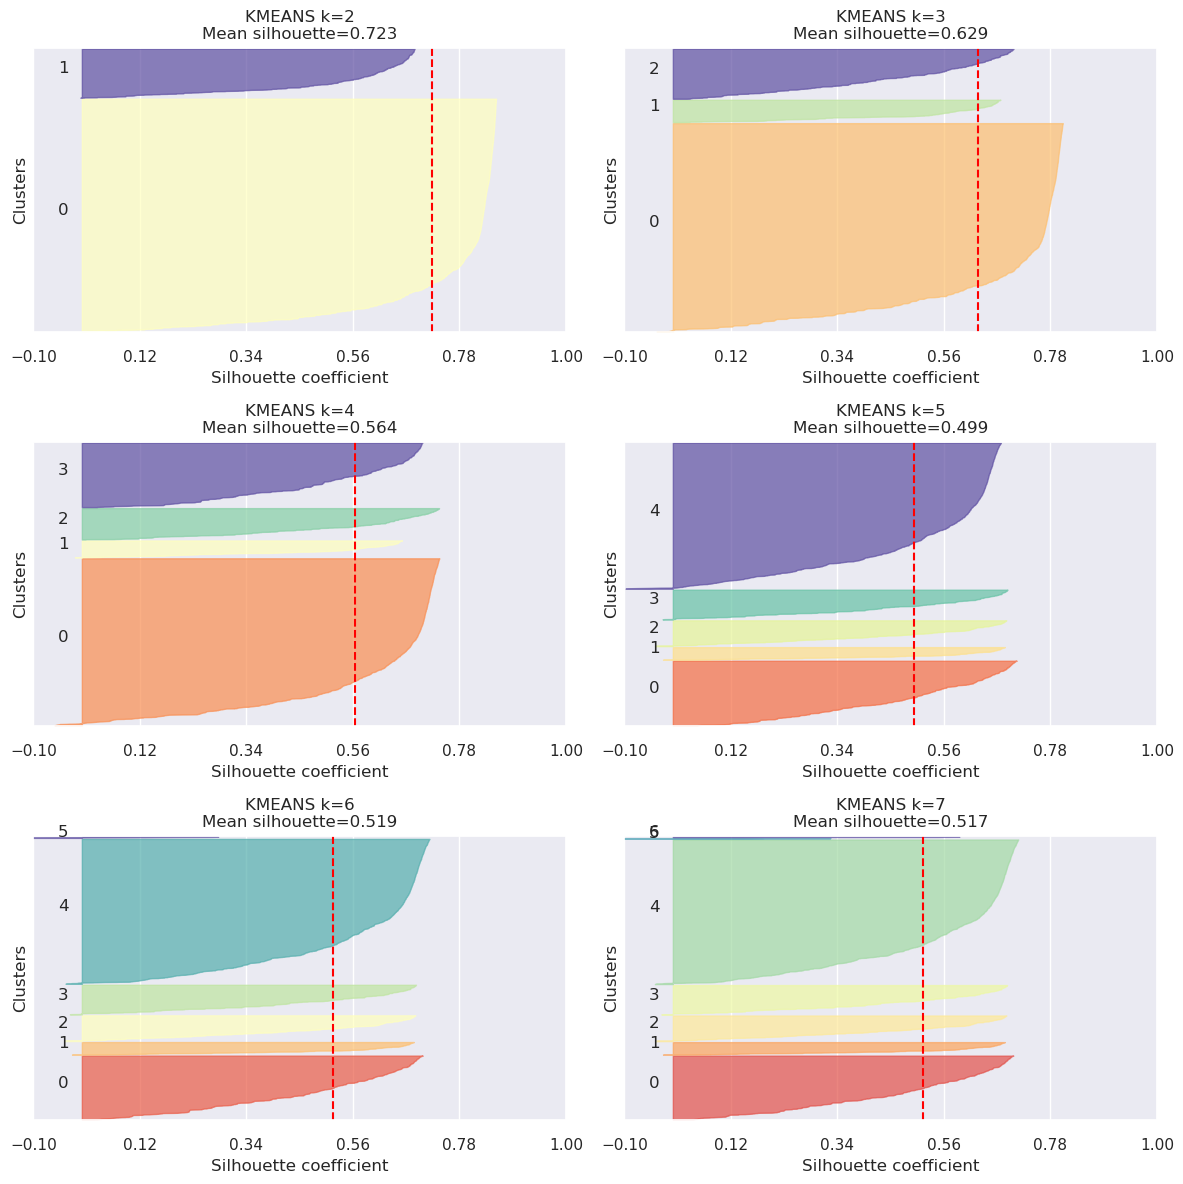

In [92]:
plot_silhouette_facet(X, clusters=[2,3,4,5,6,7], model_type="kmeans")

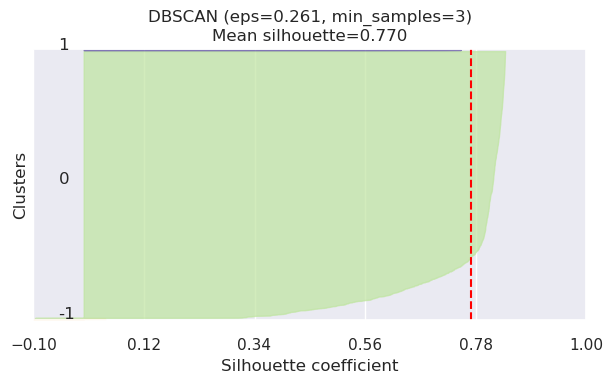

In [103]:
# DBSCAN (clusters é ignorado, usa eps/min_samples)
plot_silhouette_facet(X, clusters=[None], model_type="dbscan", eps=0.261, min_samples=3)


**DBSCAN:**  

When you encounter the scenario where "almost everything ends up in a single cluster with a few noise points," the practical interpretation is that the data does not have multiple dense, well-separated regions. In this case, a high silhouette score can be misleading: it reflects the compactness of the single cluster rather than the quality of a meaningful segmentation.  
👉 In other words, DBSCAN is more informative about anomalies than natural segments.

**KMeans:**  

This method always "force" the division into 𝑘 groups, even if there are no strong natural separations. This can be useful when the goal is to create customer personas or business segments because you need distinct groups regardless.  
👉 Even with a lower silhouette score, the resulting clusters tend to be more interpretable and actionable.

**Conclusion:**  

Since the goal is to identify groups of customers, **KMeans** with 2 groups is more suitable** for this scenario.

## <span style="color:blue">7.7</span> Whithin Sum of Squares (WSS)

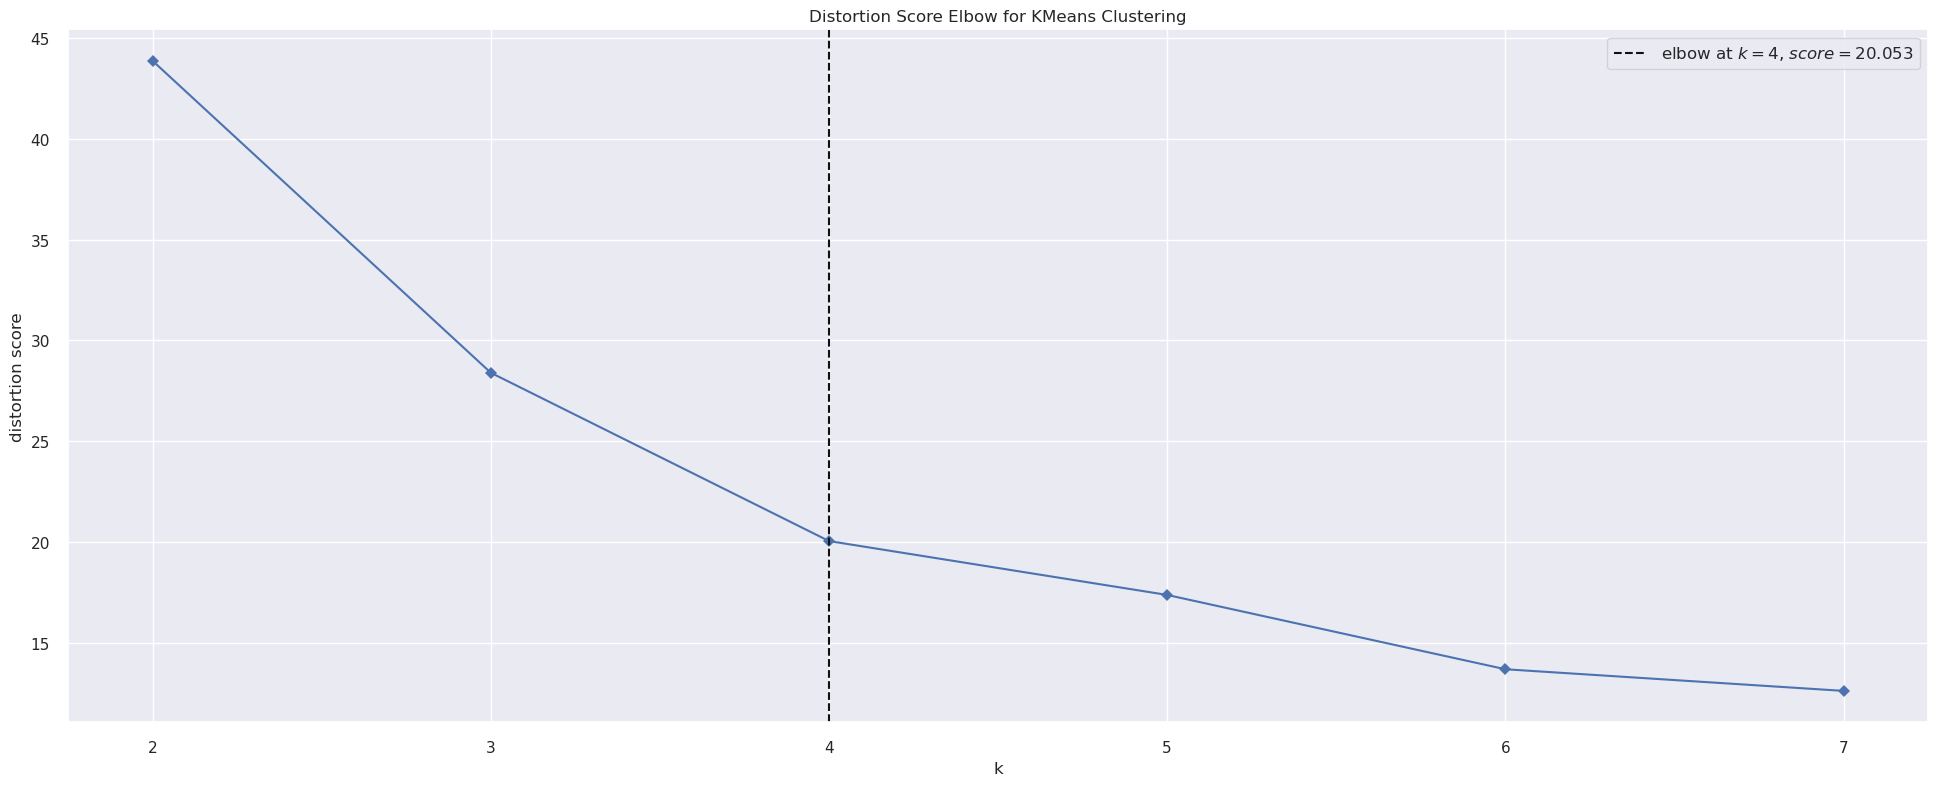

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [110]:
model = KMeans(random_state=42)

kmeans = KElbowVisualizer(model, k=clusters, timings=False)
kmeans.fit(X)
kmeans.show()


### Choosing k = 3 for Customer Segmentation

After evaluating the clustering metrics:

- The **highest silhouette score** was observed at **k = 2**, indicating that two clusters give the best balance between cohesion and separation.  
- The **lowest WSS** (Within-Cluster Sum of Squares) was achieved at **k = 4**, suggesting that four clusters yield the most compact clusters.  

To balance these two objectives — **cluster compactness** and **interpretability** — we chose **k = 3**. This value represents a **compromise between the two metrics**, providing reasonably compact clusters while maintaining clear separation, which is important for actionable customer segmentation.


# <font color='blue'> 🚀 8.0 Model Training

## <span style="color:blue">8.1</span>  K-means

In [111]:
# model definition
k = 3 
model_kmeans = KMeans(init='random', n_clusters=k, n_init=10, max_iter=300, random_state=84)

# model training
model_kmeans.fit(X)

# Clustering
labels = model_kmeans.labels_

# Check unique clusters
print(np.unique(labels))

[0 1 2]


## <span style="color:blue">8.2</span> Cluster Validation

In [112]:
## WSS (Within-cluster sum of squares)
print('WSS value: ', model_kmeans.inertia_)

## Silhouette Score
print('SS value {}:'.format( silhouette_score(X, labels, metric='euclidean') ))

WSS value:  28.103588115060884
SS value 0.5927297854186133:


# <font color='blue'> 🌐 9.0 Cluster Analysis: Unveiling Hidden Patterns

In [113]:
df9 = df6.copy()
df9['cluster'] = labels
df9.head()

,customer_id,gross_revenue,recency_days,qtde_products,frequency,qtde_returns,cluster
0,17850,0.019292,0.997319,0.037770,1.000000,0.004438,1
1,13047,0.011559,0.150134,0.021692,0.001345,0.003883,2
2,12583,0.024000,0.005362,0.029476,0.002052,0.005547,2
3,13748,0.003375,0.254692,0.003445,0.000734,0.000000,0
4,15100,0.003116,0.892761,0.000255,0.003985,0.002441,1


## <span style="color:blue">9.1</span> Visualizaion Inspection

In [115]:
# visualizer = SilhouetteVisualizer(model_kmeans, colors='yellowbrick')
# visualizer.fit(X)
# visualizer.finalize()

## <span style="color:blue">9.2</span> 2d plot

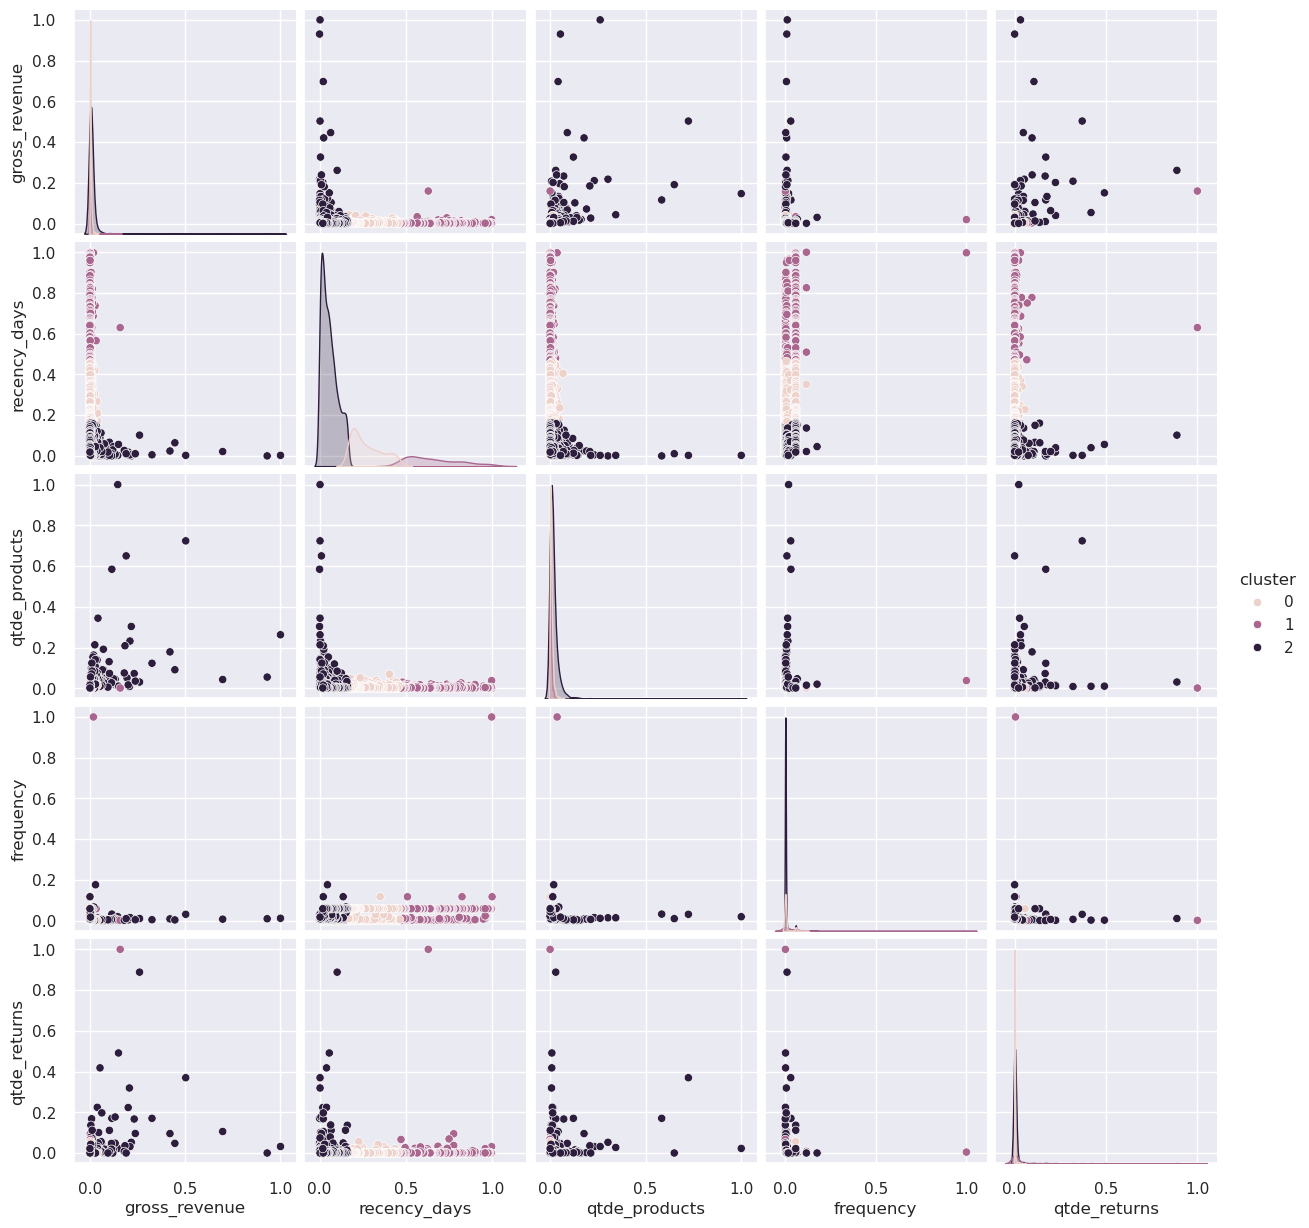

In [116]:
df_viz = df9.drop(columns=['customer_id'])
sns.pairplot(df_viz, hue='cluster')

## <span style="color:blue">9.3</span> UMAP

<Axes: xlabel='embedding_x', ylabel='embedding_y'>

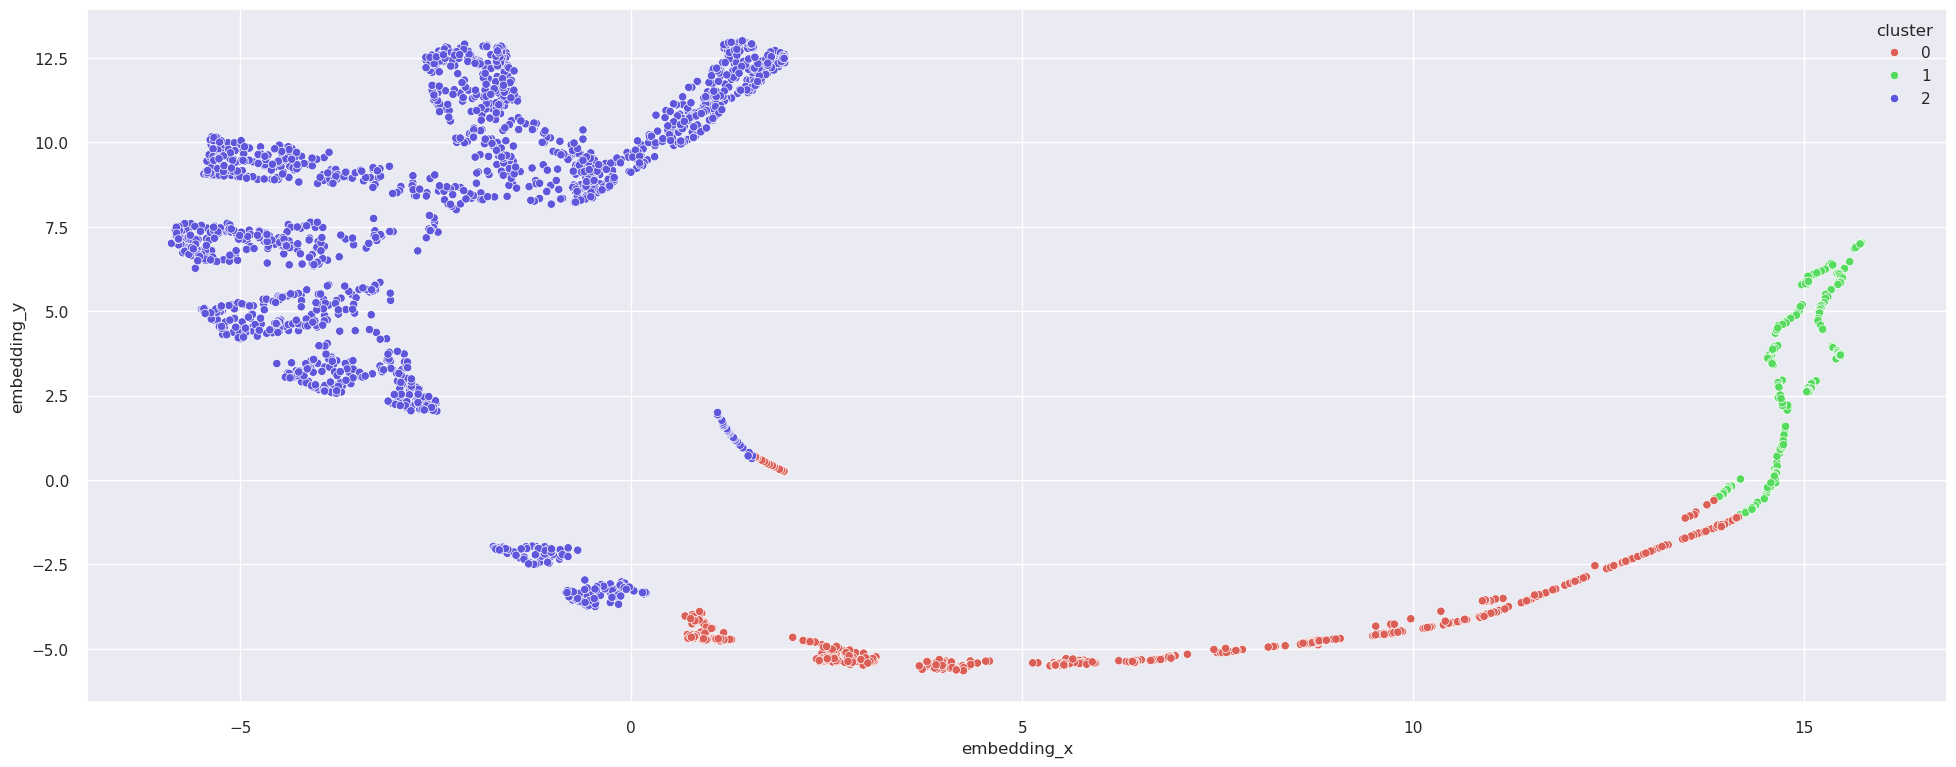

In [117]:
reducer = umap.UMAP(n_neighbors=90, random_state=42)
embedding = reducer.fit_transform(X)

# embedding
df_viz['embedding_x'] = embedding[:, 0]
df_viz['embedding_y'] = embedding[:, 1]

# plot UMAP
sns.scatterplot(x='embedding_x', y='embedding_y', hue='cluster', 
                palette= sns.color_palette('hls', n_colors=df_viz['cluster'].nunique()), 
                data=df_viz)

## <span style="color:blue">9.4</span> Cluster Profile

In [118]:
df9.head()

,customer_id,gross_revenue,recency_days,qtde_products,frequency,qtde_returns,cluster
0,17850,0.019292,0.997319,0.037770,1.000000,0.004438,1
1,13047,0.011559,0.150134,0.021692,0.001345,0.003883,2
2,12583,0.024000,0.005362,0.029476,0.002052,0.005547,2
3,13748,0.003375,0.254692,0.003445,0.000734,0.000000,0
4,15100,0.003116,0.892761,0.000255,0.003985,0.002441,1


In [132]:
numerical_columns = ['customer_id', 'gross_revenue', 'recency_days', 'qtde_products', 'frequency', 'qtde_returns']

# get data pre transformation with MinMaxScaler
df94 = df4[numerical_columns].copy()

# Fazendo o join pelo customer_id
df94 = df94.merge(
    df9[['customer_id', 'cluster']],  # pega só a coluna cluster
    on='customer_id',                 # chave do join
    how='left'                        # mantém todos os registros de df94
)

# Verifica o resultado
df94.head()

,customer_id,gross_revenue,recency_days,qtde_products,frequency,qtde_returns,cluster
0,17850,5391.21,372.0,297.0,17.000000,40.0,1
1,13047,3232.59,56.0,171.0,0.028302,35.0,2
2,12583,6705.38,2.0,232.0,0.040323,50.0,2
3,13748,948.25,95.0,28.0,0.017921,0.0,0
4,15100,876.00,333.0,3.0,0.073171,22.0,1


In [ ]:
# Number os customers
df_cluster = df94[['cluster', 'customer_id']].groupby('cluster').count().reset_index().rename(columns={'customer_id': 'count_customer'})
df_cluster['perc_customer'] = df_cluster['count_customer'] / df_cluster['count_customer'].sum() * 100

# Avg Gross Revenue
df_cluster['avg_gross_revenue'] = df94[['cluster', 'gross_revenue']].groupby('cluster').mean().reset_index()['gross_revenue']

# Avg Recency Days
df_cluster['avg_recency_days'] = df94[['cluster', 'recency_days']].groupby('cluster').mean().reset_index()['recency_days']

# Avg Quantity of Products
df_cluster['avg_qtde_products'] = df94[['cluster', 'qtde_products']].groupby('cluster').mean().reset_index()['qtde_products']

# Avg Frequency
df_cluster['avg_frequency'] = df94[['cluster', 'frequency']].groupby('cluster').mean().reset_index()['frequency']

# Avg Returns
df_cluster['avg_returns'] = df94[['cluster', 'qtde_returns']].groupby('cluster').mean().reset_index()['qtde_returns']


,cluster,count_customer,perc_customer,avg_gross_revenue,avg_recency_days,avg_qtde_products,avg_frequency,avg_returns
0,0,652,21.967655,1205.066457,102.593558,62.000000,0.118220,9.656442
1,1,333,11.219677,860.759520,246.252252,37.672673,0.402817,47.462462
2,2,1983,66.812668,3490.634095,21.168432,157.032779,0.063861,41.073122


## Customer Segmentation Results (3 Clusters)

### Cluster 00 – **Moderate-Value Customers (Average Recency & Revenue)**
- Represent about **22% of the customer base**.  
- **Average recency (≈103 days)** – customers are not very recent, but still somewhat engaged.  
- **Moderate purchase frequency** and **medium ticket size**.  
- Generate **reasonable revenue per customer**, though not top contributors.  
- Represent a **stable mid-tier group** with potential to grow through engagement strategies.  

---

### Cluster 01 – **Low-Value & Inactive Customers**
- Smallest group (**≈11% of customers**).  
- **Very high recency (≈246 days)** – customers have not purchased in a long time.  
- **Low revenue** and **low product quantity purchased**.  
- Show **higher returns rate**, indicating weaker satisfaction or mismatched expectations.  
- Represent **disengaged or at-risk customers**, requiring reactivation or churn-prevention campaigns.  

---

### Cluster 02 – **High-Value & Highly Engaged Customers**
- Largest segment (**≈67% of customers**).  
- **Very recent purchases (≈21 days)**, showing strong ongoing engagement.  
- **Highest revenue per customer** and **highest number of products purchased**.  
- **Low frequency but high basket size**, suggesting fewer but more valuable transactions.  
- Represent the **core high-value group**, crucial for business performance and ideal for loyalty programs or premium offerings.  


# <font color='blue'> ✨ 10.0 Deploy to Production